In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
sns.set_style('whitegrid')
sns.set_palette("Set2")

%matplotlib inline

# Leer los datos

In [50]:
df_fe = pd.read_csv("../../data/respuestas_fede.csv")
print(df_fe.shape)

#globales
marmol = df_fe.loc[df_fe["escuela"] == "Colegio Modelo Mármol"]
mantovani = df_fe.loc[df_fe["escuela"] == "Escuela Nueva Juan Mantovani"]
cant_total = len(df_fe)
cant_marmol = len(marmol)
cant_mantovani = len(mantovani)
# genero
cant_marmol_masc = len(marmol[marmol['genero']=="Masculino"])
cant_marmol_fem = len(marmol[marmol['genero']=="Femenino"])
cant_mantovani_masc = len(mantovani[mantovani['genero']=="Masculino"])
cant_mantovani_fem = len(mantovani[mantovani['genero']=="Femenino"])
# grados
cant_marmol_quinto = len(marmol[marmol['grado']=="Quinto"])
cant_marmol_sexto = len(marmol[marmol['grado']=="Sexto"])
cant_mantovani_cuarto = len(mantovani[mantovani['grado']=="Cuarto"])
cant_mantovani_quinto = len(mantovani[mantovani['grado']=="Quinto"])
cant_mantovani_sexto = len(mantovani[mantovani['grado']=="Sexto"])
# nose que es la nube
nube_nose_totales   = df_fe    ["que_es_nube"].value_counts()["No sé"]
nube_nose_marmol    = marmol   ["que_es_nube"].value_counts()["No sé"]
nube_nose_mantovani = mantovani["que_es_nube"].value_counts()["No sé"]
# no se nube grados
nube_nose_marmol_quinto = marmol[marmol['grado']=="Quinto"]["que_es_nube"].value_counts()["No sé"]
nube_nose_marmol_sexto = marmol[marmol['grado']=="Sexto"]["que_es_nube"].value_counts()["No sé"]
nube_nose_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["que_es_nube"].value_counts()["No sé"]
nube_nose_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["que_es_nube"].value_counts()["No sé"]
nube_nose_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["que_es_nube"].value_counts()["No sé"]
# no se nube generos
nube_nose_marmol_masc    = marmol[marmol['genero']=="Masculino"]["que_es_nube"].value_counts()["No sé"]
nube_nose_marmol_fem     = marmol[marmol['genero']=="Femenino"]["que_es_nube"].value_counts()["No sé"]
nube_nose_mantovani_masc = mantovani[mantovani['genero']=="Masculino"]["que_es_nube"].value_counts()["No sé"]
nube_nose_mantovani_fem  = mantovani[mantovani['genero']=="Femenino"]["que_es_nube"].value_counts()["No sé"]
# no use wikipedia
wiki_no_totales          = df_fe    ["uso_wikipedia"].value_counts()["No"]
wiki_no_marmol           = marmol   ["uso_wikipedia"].value_counts()["No"]
wiki_no_mantovani        = mantovani["uso_wikipedia"].value_counts()["No"]
# no use wikipedia grados
wiki_no_marmol_quinto    = marmol[marmol['grado']=="Quinto"]["uso_wikipedia"].value_counts()["No"]
wiki_no_marmol_sexto     = marmol[marmol['grado']=="Sexto"]["uso_wikipedia"].value_counts()["No"]
wiki_no_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["uso_wikipedia"].value_counts()["No"]
wiki_no_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["uso_wikipedia"].value_counts()["No"]
wiki_no_mantovani_sexto  = mantovani[mantovani['grado']=="Sexto"]["uso_wikipedia"].value_counts()["No"]
# no use wikipedia genero
wiki_no_marmol_masc      = marmol[marmol['genero']=="Masculino"]["uso_wikipedia"].value_counts()["No"]
wiki_no_marmol_fem       = marmol[marmol['genero']=="Femenino"]["uso_wikipedia"].value_counts()["No"]
wiki_no_mantovani_masc   = mantovani[mantovani['genero']=="Masculino"]["uso_wikipedia"].value_counts()["No"]
wiki_no_mantovani_fem    = mantovani[mantovani['genero']=="Femenino"]["uso_wikipedia"].value_counts()["No"]

(369, 22)
15 6 9


## ¿Dónde se almacenan los videos que están en YouTube? 

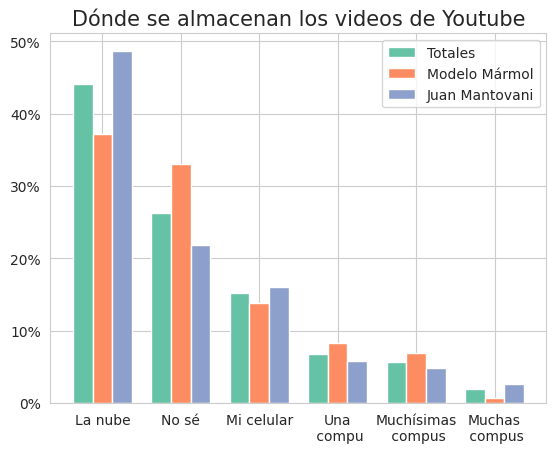

In [35]:
# ¿Dónde se almacenan los videos que están en YouTube? 
data_total = df_fe["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"En la nube": "La nube",
                              "En mi celular": "Mi celular",
                              "En una computadora": "Una\n compu",
                              "En muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\n compus",
                              "En muchas computadoras (tantas que podrían llenar una casa)": "Muchas\n compus"}).fillna(0)

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Dónde se almacenan los videos de Youtube", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('donde_youtube.png')

* En ambos vemos las respuestas la nube y nose como las mas elegidas
* Menos de un 10% elige la opción sin misconception, si sumamos no sé llegamos a un 40% sin misc. en el Modelo Mármol y un 30% en el Mantovani. -> Este analisis debería estar a parte en otros gráficos creo.

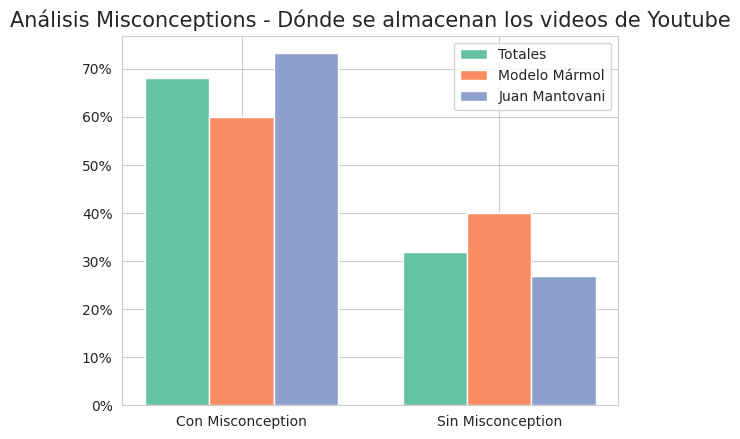

In [50]:
# Con misconception vs Sin Misconception - Agrupando No se - ¿Dónde se almacenan los videos que están en YouTube?
data_total = df_fe["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"En la nube": "La nube",
                              "En mi celular": "Mi celular",
                              "En una computadora": "Una\n compu",
                              "En muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\n compus",
                              "En muchas computadoras (tantas que podrían llenar una casa)": "Muchas\n compus"}).fillna(0)

df_con_mis = result.loc[(result.index != 'No sé') & (result.index != 'Muchísimas\n compus')].sum()
df_sin_mis = result.loc[(result.index == 'No sé') | (result.index == 'Muchísimas\n compus')].sum()

result = pd.concat([df_con_mis, df_sin_mis], axis=1, ignore_index=True).rename(columns={0: "Con Misconception", 1: "Sin Misconception"}).transpose()

bar_width = 0.25

br1 = np.arange(len(result['Totales']))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions - Dónde se almacenan los videos de Youtube", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('misconc_agreg_donde_youtube.png')

* Cerca de un 70% presenta misconceptions en promedio. Estos son alumnos que no Eligen "No se", ni "Muchisimas computadoras"
* En el modelo mármol estamos cerca del 60%
* En el Mantovani por encima del 70%

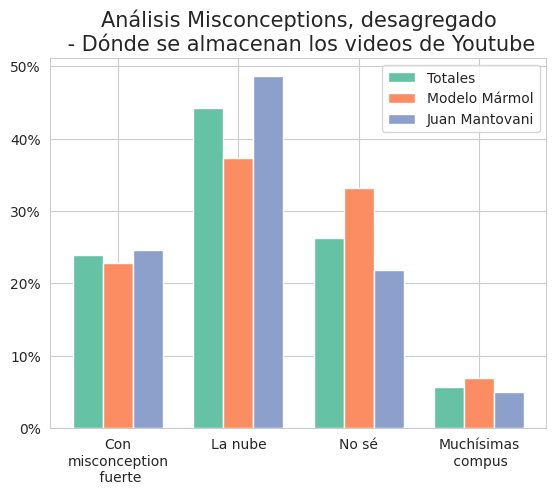

In [52]:
# Con misconception vs Sin Misconception - Agrupando No se - ¿Dónde se almacenan los videos que están en YouTube?
data_total = df_fe["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"En la nube": "La nube",
                              "En mi celular": "Mi celular",
                              "En una computadora": "Una\n compu",
                              "En muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\n compus",
                              "En muchas computadoras (tantas que podrían llenar una casa)": "Muchas\n compus"}).fillna(0)

df_con_mis_fuerte = result.loc[(result.index != 'La nube') & 
                        (result.index != 'No sé') & 
                        (result.index != 'Muchísimas\n compus')].sum()


result = pd.concat([ df_con_mis_fuerte, 
                     result.loc[result.index=='La nube'].sum(),
                     result.loc[result.index=='No sé'].sum(),
                     result.loc[result.index=='Muchísimas\n compus'].sum(),
                     ], axis=1, ignore_index=True).rename(columns={0: "Con\nmisconception\n fuerte",
                                                                   1: "La nube",
                                                                   2: "No sé",
                                                                   3: "Muchísimas\n compus"}).transpose()

bar_width = 0.25

br1 = np.arange(len(result['Totales']))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions, desagregado\n - Dónde se almacenan los videos de Youtube", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('misconc_desagreg_donde_youtube.png')

* En este grafico desagregamos las "misconceptions fuertes" (Mi celular, Una computadora, Muchas compus) de las debiles (La nube), y las respuestas sin misconception (No se, Muchisimas compus)
* Podemos ver que la misconception mas significativa es "la nube" que no es misconception fuerte. En cuanto a las respuestas sin misconception, No se es la mas significativa.
* Conclusion: hay tendencia a una misconception debil en torno a donde se guardan los videos en youtube

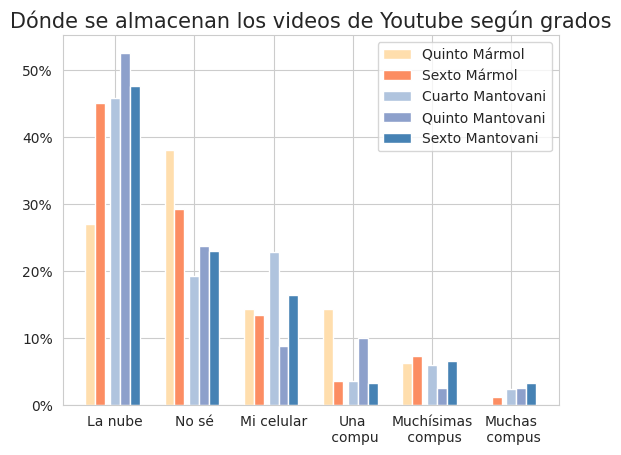

In [28]:
# ¿Dónde se almacenan los videos que están en YouTube? - Grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                        index={"En la nube": "La nube",
                              "En mi celular": "Mi celular",
                              "En una computadora": "Una\n compu",
                              "En muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\n compus",
                              "En muchas computadoras (tantas que podrían llenar una casa)": "Muchas\n compus"}).fillna(0)

result = result.reindex(["La nube", 
                         "No sé",
                         "Mi celular", 
                         "Una\n compu",
                         "Muchísimas\n compus",
                         "Muchas\n compus"])

bar_width = 0.25

br1 = [1, 3, 5, 7, 9, 11]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Dónde se almacenan los videos de Youtube según grados", fontsize=15)
plt.xticks([x + 2.5*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('donde_youtube_grados.png')


* Modelo Mármol: La nube es un 10% mas elegida de 5to a 6to. No sé y una Compu un 10% menos elegida de 4to a 5to.
* Mantovani: Mi celular varía entre 4to a 6to.


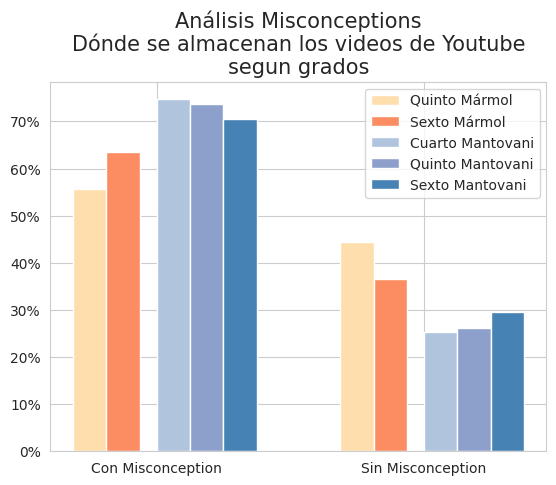

In [62]:
# Con misconception vs Sin Misconception - Agrupando No se - ¿Dónde se almacenan los videos que están en YouTube? - segun grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                       index={"En la nube": "La nube",
                              "En mi celular": "Mi celular",
                              "En una computadora": "Una\n compu",
                              "En muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\n compus",
                              "En muchas computadoras (tantas que podrían llenar una casa)": "Muchas\n compus"}).fillna(0)

# print(result)

df_con_mis = result.loc[(result.index != 'No sé') & (result.index != 'Muchísimas\n compus')].sum()
df_sin_mis = result.loc[(result.index == 'No sé') | (result.index == 'Muchísimas\n compus')].sum()

result = pd.concat([df_con_mis, df_sin_mis], axis=1, ignore_index=True).rename(columns={0: "Con Misconception", 1: "Sin Misconception"}).transpose()

bar_width = 0.25

br1 = [1,3]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions\nDónde se almacenan los videos de Youtube\nsegun grados", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend()
plt.savefig('misconc_agreg_donde_youtube_grados.png')

* En el Modelo marmol contestan con mas misconceptions en grados mas altos
* En el Mantovani bajan levemente el porcentaje de misconceptions

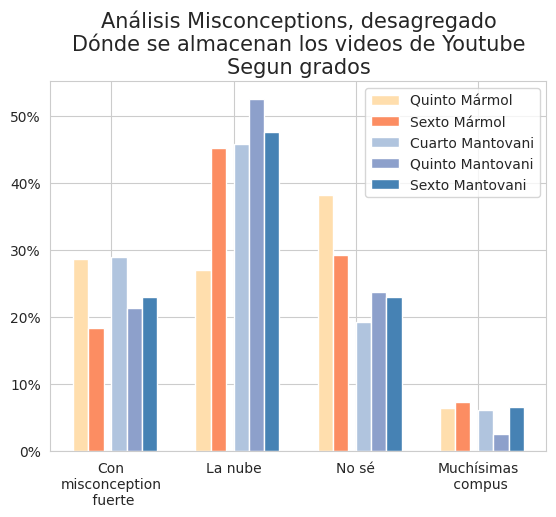

In [65]:
# Con misconception vs Sin Misconception - desagrupando No se - ¿Dónde se almacenan los videos que están en YouTube? - segun grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                       index={"En la nube": "La nube",
                              "En mi celular": "Mi celular",
                              "En una computadora": "Una\n compu",
                              "En muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\n compus",
                              "En muchas computadoras (tantas que podrían llenar una casa)": "Muchas\n compus"}).fillna(0)

df_con_mis_fuerte = result.loc[(result.index != 'La nube') & 
                        (result.index != 'No sé') & 
                        (result.index != 'Muchísimas\n compus')].sum()


result = pd.concat([ df_con_mis_fuerte, 
                     result.loc[result.index=='La nube'].sum(),
                     result.loc[result.index=='No sé'].sum(),
                     result.loc[result.index=='Muchísimas\n compus'].sum(),
                     ], axis=1, ignore_index=True).rename(columns={0: "Con\nmisconception\n fuerte",
                                                                   1: "La nube",
                                                                   2: "No sé",
                                                                   3: "Muchísimas\n compus"}).transpose()

bar_width = 0.25

br1 = [1,3,5,7]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions, desagregado\nDónde se almacenan los videos de Youtube\nSegun grados", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend()
plt.savefig('misconc_desagreg_donde_youtube_grados.png')

* Si bien en el marmol aumentan en misconception de 5to a 6to, bajan mucho el % de misconception fuerte y responden mas "la nube". Sin embargo tambien responden menos "No se" en favor de esta respuesta, cambiando una "no miscon" por una si.
* En el Mantovani tambien responden menos con una misconception fuerte y tambien suben la respuesta "la nube". Sin embargo aumentan levemente respuestas sin misconception: "No se" y "Muchisimas compus"

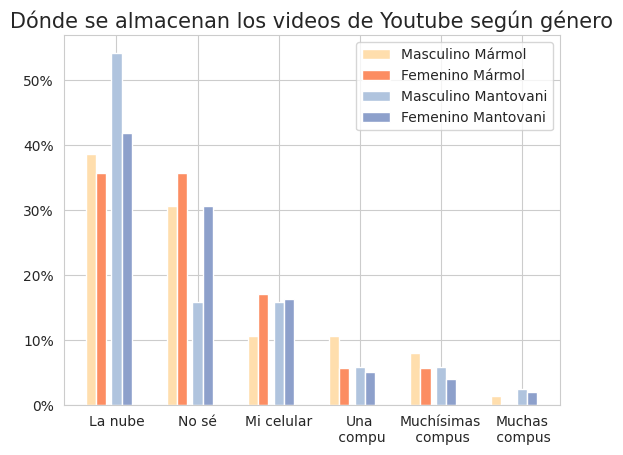

In [29]:
# ¿Dónde se almacenan los videos que están en YouTube? - Género
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 1: "Femenino Mármol", 2: "Masculino Mantovani", 3: "Femenino Mantovani"},
                       index={"En la nube": "La nube",
                              "En mi celular": "Mi celular",
                              "En una computadora": "Una\n compu",
                              "En muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\n compus",
                              "En muchas computadoras (tantas que podrían llenar una casa)": "Muchas\n compus"}).fillna(0)

result = result.reindex(["La nube", 
                         "No sé",
                         "Mi celular", 
                         "Una\n compu",
                         "Muchísimas\n compus",
                         "Muchas\n compus"])

bar_width = 0.25

br1 = [1, 3, 5, 7, 9, 11]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Dónde se almacenan los videos de Youtube según género", fontsize=15)
plt.xticks([x + 2.5*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('donde_youtube_genero.png')

* Mármol: No hay diferencias notorias.
* Mantovani: un 10% más de los varones eligen la opción de La nube. Un 15 % más de las mujeres eligen No se.

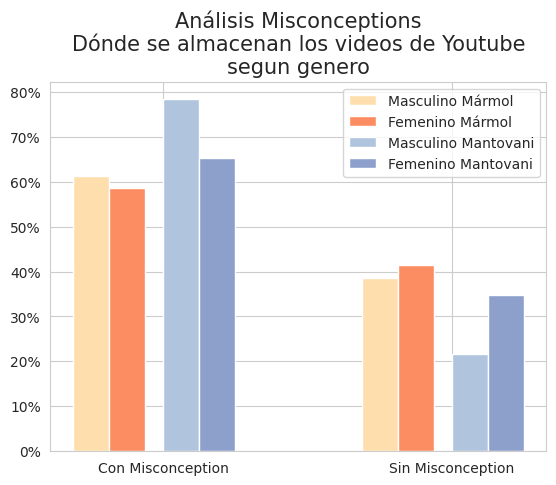

In [76]:
# Con misconception vs Sin Misconception - Agrupando No se - ¿Dónde se almacenan los videos que están en YouTube? - segun genero
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 
                                1: "Femenino Mármol",
                                2: "Masculino Mantovani",
                                3: "Femenino Mantovani"},
                       index={"En la nube": "La nube",
                              "En mi celular": "Mi celular",
                              "En una computadora": "Una\n compu",
                              "En muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\n compus",
                              "En muchas computadoras (tantas que podrían llenar una casa)": "Muchas\n compus"}).fillna(0)

df_con_mis = result.loc[(result.index != 'No sé') & (result.index != 'Muchísimas\n compus')].sum()
df_sin_mis = result.loc[(result.index == 'No sé') | (result.index == 'Muchísimas\n compus')].sum()

result = pd.concat([df_con_mis, df_sin_mis], axis=1, ignore_index=True).rename(columns={0: "Con Misconception", 1: "Sin Misconception"}).transpose()

bar_width = 0.25

br1 = [1,3]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions\nDónde se almacenan los videos de Youtube\nsegun genero", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend()
plt.savefig('misconc_agreg_donde_youtube_genero.png')

* No hay grandes diferencias en el Marmol
* En el mantovani, Los varones contestan con un 10% mas de misconceptions

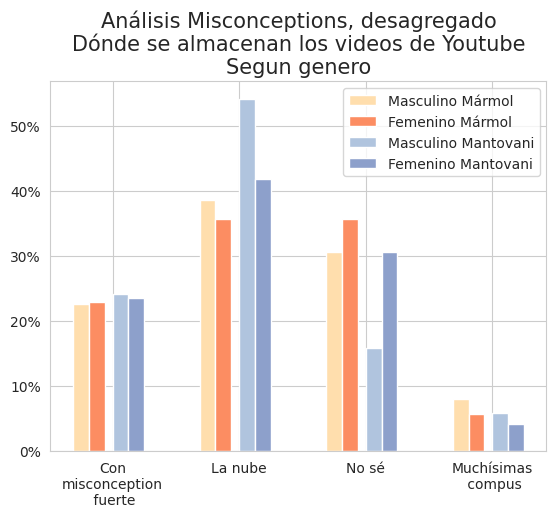

In [77]:
# Con misconception vs Sin Misconception - desagrupando No se - ¿Dónde se almacenan los videos que están en YouTube? - segun genero
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 
                                1: "Femenino Mármol",
                                2: "Masculino Mantovani",
                                3: "Femenino Mantovani"},
                       index={"En la nube": "La nube",
                              "En mi celular": "Mi celular",
                              "En una computadora": "Una\n compu",
                              "En muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\n compus",
                              "En muchas computadoras (tantas que podrían llenar una casa)": "Muchas\n compus"}).fillna(0)

df_con_mis_fuerte = result.loc[(result.index != 'La nube') & 
                        (result.index != 'No sé') & 
                        (result.index != 'Muchísimas\n compus')].sum()


result = pd.concat([ df_con_mis_fuerte, 
                     result.loc[result.index=='La nube'].sum(),
                     result.loc[result.index=='No sé'].sum(),
                     result.loc[result.index=='Muchísimas\n compus'].sum(),
                     ], axis=1, ignore_index=True).rename(columns={0: "Con\nmisconception\n fuerte",
                                                                   1: "La nube",
                                                                   2: "No sé",
                                                                   3: "Muchísimas\n compus"}).transpose()

bar_width = 0.25

br1 = [1,3,5,7]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions, desagregado\nDónde se almacenan los videos de Youtube\nSegun genero", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend()
plt.savefig('misconc_desagreg_donde_youtube_genero.png')

* En el marmol no hay mucha diferencia con el genero
* En el mantovani los varones responden un 10% mas con la misconception debil "la nube" y las mujeres un 15% mas con la respuesta sin misconception "no se"

# ¿Quién tiene acceso a las fotos que tengo guardadas en mi celular?

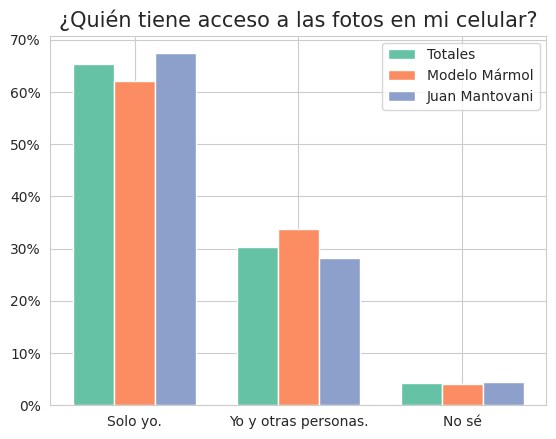

In [31]:
# Quien tiene acceso a las fotos en mi celular
data_total = df_fe["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"})

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("¿Quién tiene acceso a las fotos en mi celular?", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('quien_acceso_celular.png')

* Solo yo es un 5% más elegida en el Mantovani.
* Yo y otras personas un 5% más en el Mármol.

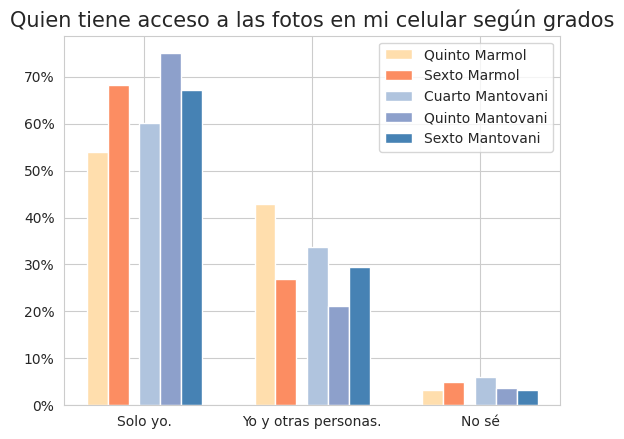

In [32]:
# Quien tiene acceso a las fotos en mi celular - Grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Marmol',
                                1:'Sexto Marmol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'})

bar_width = 0.25

br1 = [1, 3, 5]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Marmol']    , width=bar_width, label = 'Quinto Marmol', color='navajowhite')
plt.bar(br2, result['Sexto Marmol']     , width=bar_width, label = 'Sexto Marmol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Quien tiene acceso a las fotos en mi celular según grados", fontsize=15)
plt.xticks([x + 2.25*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('quien_acceso_celular_grados.png')

* Mármol: Solo yo un 15% más seleccionado de 5to a 6to. Yo y otras peronas un 15% menos seleccionado de 5to a 6to.
* Mantovani: Las variaciones son iguales pero en menor porcentaje para el Mantovani. Aumentan solo yo al crecer y cecrementan yo y otras personas.

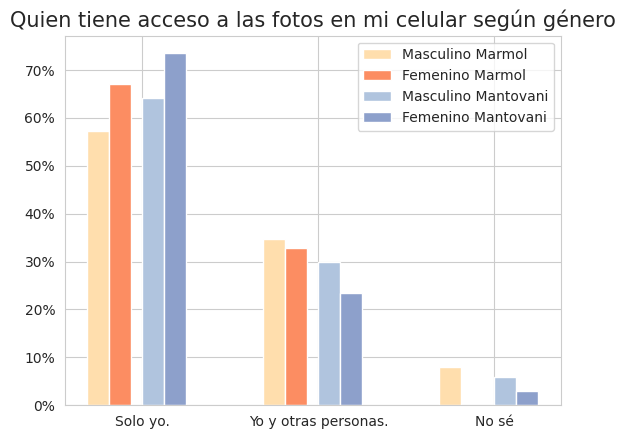

In [33]:
# Quien tiene acceso a las fotos en mi celular - Género
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Marmol", 1: "Femenino Marmol", 2: "Masculino Mantovani", 3: "Femenino Mantovani"})

bar_width = 0.25

br1 = [1, 3, 5]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Marmol"],     width=bar_width, label = 'Masculino Marmol', color='navajowhite')
plt.bar(br2,result["Femenino Marmol"],      width=bar_width, label = 'Femenino Marmol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Quien tiene acceso a las fotos en mi celular según género", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('quien_acceso_celular_genero.png')

En ambos colegios Solo yo es un 10% más elegido por las chicas y yo y otras peronas es un 5% menos elegido por las chicas

# Cuando le mando a una amiga una foto por WhatsApp..

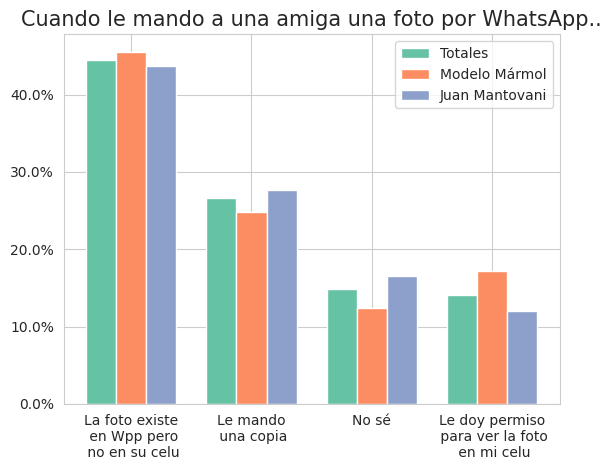

In [37]:
# Cuando le mando a una amiga una foto por WhatsApp..
data_total = df_fe["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"La foto ahora existe en WhatsApp y mi amiga la puede ver cuando mira nuestro chat, pero no la tiene en su celular":"La foto existe\n en Wpp pero\n no en su celu",
                              "Le mando una copia de mi foto.": "Le mando\n una copia",
                              "Le doy permiso para ver la foto que tengo guardada en mi celular.": "Le doy permiso\n para ver la foto\n en mi celu"}).fillna(0)

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Cuando le mando a una amiga una foto por WhatsApp..", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('amiga_wpp.png')

* En el Mármol contestan No sé un 5% menos que en el Mantovani.
* Mármol contesta 5% más "Le doy permiso" que el Mantovani.

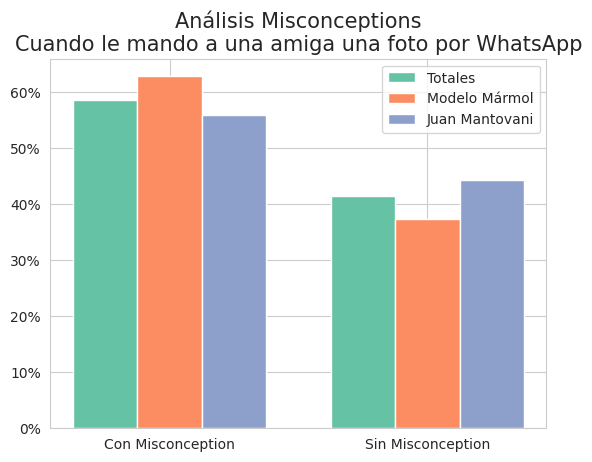

In [3]:
# Con misconception vs Sin Misconception - Agrupando No se - Cuando le mando a una amiga una foto por WhatsApp
data_total = df_fe["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"La foto ahora existe en WhatsApp y mi amiga la puede ver cuando mira nuestro chat, pero no la tiene en su celular":"La foto existe\n en Wpp pero\n no en su celu",
                              "Le mando una copia de mi foto.": "Le mando\n una copia",
                              "Le doy permiso para ver la foto que tengo guardada en mi celular.": "Le doy permiso\n para ver la foto\n en mi celu"}).fillna(0)

df_con_mis = result.loc[(result.index != 'No sé') & (result.index != 'Le mando\n una copia')].sum()
df_sin_mis = result.loc[(result.index == 'No sé') | (result.index == 'Le mando\n una copia')].sum()

result = pd.concat([df_con_mis, df_sin_mis], axis=1, ignore_index=True).rename(columns={0: "Con Misconception", 1: "Sin Misconception"}).transpose()

bar_width = 0.25

br1 = np.arange(len(result['Totales']))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions\nCuando le mando a una amiga una foto por WhatsApp", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('misconc_agreg_amiga_wpp.png')

* Ambos colegios tienen cerca de un promedio de 60% de respuestas con misconception

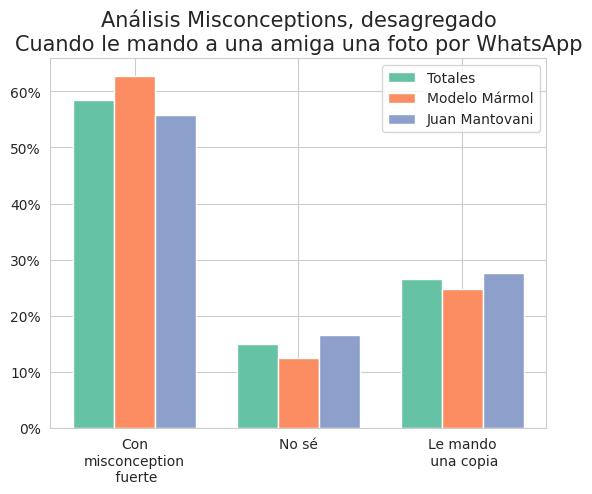

In [6]:
# Con misconception vs Sin Misconception - Desagrupando No se - Cuando le mando a una amiga una foto por WhatsApp
data_total = df_fe["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"La foto ahora existe en WhatsApp y mi amiga la puede ver cuando mira nuestro chat, pero no la tiene en su celular":"La foto existe\n en Wpp pero\n no en su celu",
                              "Le mando una copia de mi foto.": "Le mando\n una copia",
                              "Le doy permiso para ver la foto que tengo guardada en mi celular.": "Le doy permiso\n para ver la foto\n en mi celu"}).fillna(0)

df_con_mis_fuerte = result.loc[(result.index == 'La foto existe\n en Wpp pero\n no en su celu') |
                        (result.index == 'Le doy permiso\n para ver la foto\n en mi celu')].sum()


result = pd.concat([ df_con_mis_fuerte,
                     result.loc[result.index=='No sé'].sum(),
                     result.loc[result.index=='Le mando\n una copia'].sum(),
                     ], axis=1, ignore_index=True).rename(columns={0: "Con\nmisconception\n fuerte",
                                                                   1: "No sé",
                                                                   2: "Le mando\n una copia"}).transpose()

bar_width = 0.25

br1 = np.arange(len(result['Totales']))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions, desagregado\nCuando le mando a una amiga una foto por WhatsApp", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('misconc_desagreg_amiga_wpp.png')

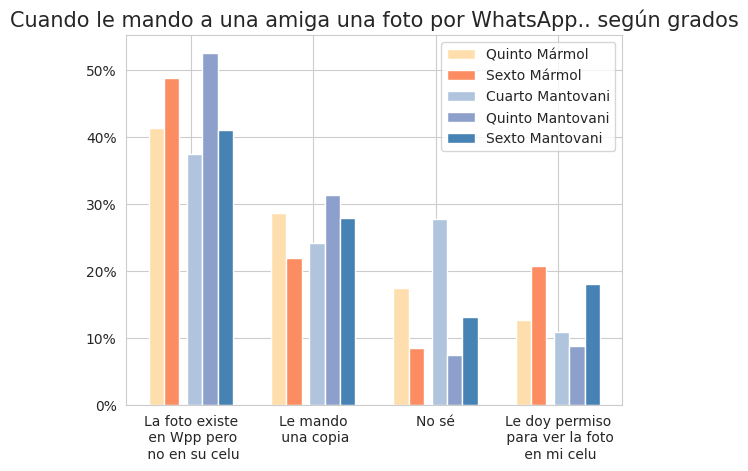

In [40]:
# Cuando le mando a una amiga una foto por WhatsApp.. - Grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                       index={"La foto ahora existe en WhatsApp y mi amiga la puede ver cuando mira nuestro chat, pero no la tiene en su celular":"La foto existe\n en Wpp pero\n no en su celu",
                              "Le mando una copia de mi foto.": "Le mando\n una copia",
                              "Le doy permiso para ver la foto que tengo guardada en mi celular.": "Le doy permiso\n para ver la foto\n en mi celu"}).fillna(0)

result = result.reindex(["La foto existe\n en Wpp pero\n no en su celu",
                         "Le mando\n una copia",
                         "No sé",
                         "Le doy permiso\n para ver la foto\n en mi celu"])

bar_width = 0.25

br1 = [1, 3, 5, 7]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Cuando le mando a una amiga una foto por WhatsApp.. según grados", fontsize=15)
plt.xticks([x + 2.25*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('amiga_wpp_grados.png')

* No se aprecia un patrón que se repita en ambos colegios porque 5to del Mantovani no está entre los datos de 4to y 6to. 
* La foto existe en wpp es más elegida en alumnes más grandes en el Mármol. Tambien en el Mantovani de 4to a 6to y de 4to a 5to pero cambia en un 10% el porcentaje de 5to a 6to.
* Le mando una copia se mantiene similar en ambos colegios.
* No se es un 10% menos elegida en chicos más grandes en el Modelo y un 20% menos en el Mantovani entre los de 5to y 6to respecto a los de 4to.
* Le doy permiso es un 10% más elegida en chicos de 6to para ambos colegios

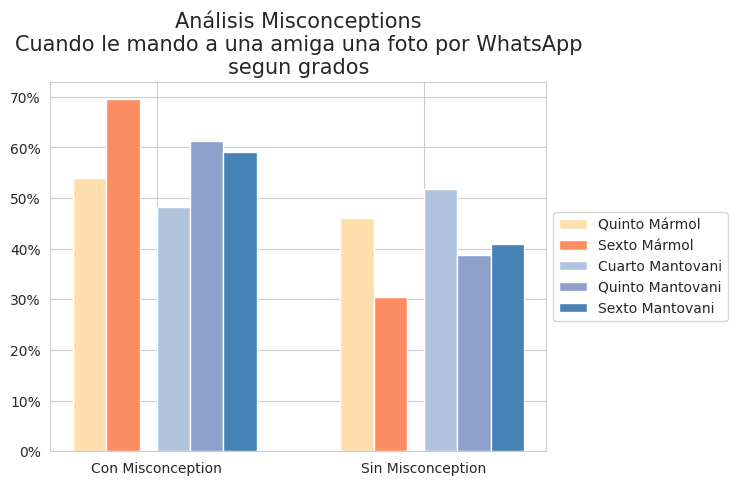

In [3]:
# Con misconception vs Sin Misconception - Agrupando No se - Cuando le mando a una amiga una foto por WhatsApp - segun grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                       index={"La foto ahora existe en WhatsApp y mi amiga la puede ver cuando mira nuestro chat, pero no la tiene en su celular":"La foto existe\n en Wpp pero\n no en su celu",
                              "Le mando una copia de mi foto.": "Le mando\n una copia",
                              "Le doy permiso para ver la foto que tengo guardada en mi celular.": "Le doy permiso\n para ver la foto\n en mi celu"}).fillna(0)

# print(result)

df_con_mis = result.loc[(result.index != 'No sé') & (result.index != 'Le mando\n una copia')].sum()
df_sin_mis = result.loc[(result.index == 'No sé') | (result.index == 'Le mando\n una copia')].sum()

result = pd.concat([df_con_mis, df_sin_mis], axis=1, ignore_index=True).rename(columns={0: "Con Misconception", 1: "Sin Misconception"}).transpose()

bar_width = 0.25

br1 = [1,3]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions\nCuando le mando a una amiga una foto por WhatsApp\nsegun grados", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig('misconc_agreg_amiga_wpp_grados.png')

* Nuevamente vemos el Modelo marmol aumentar la misconception en grados mas altos y esta vez ocurre lo mismo en el mantovani

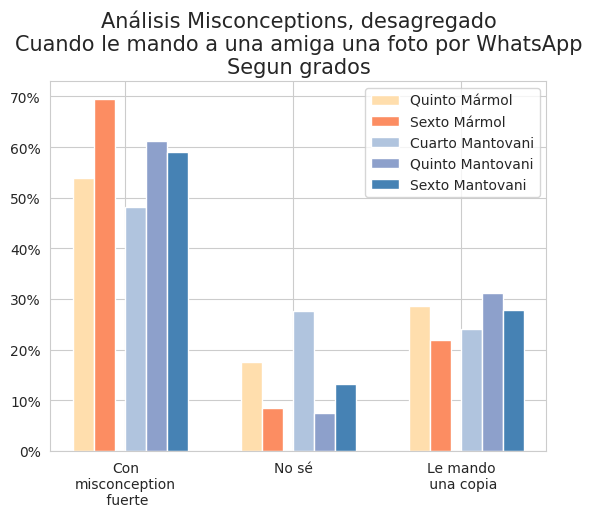

In [15]:
# Con misconception vs Sin Misconception - desagrupando No se - Cuando le mando a una amiga una foto por WhatsApp - segun grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                       index={"La foto ahora existe en WhatsApp y mi amiga la puede ver cuando mira nuestro chat, pero no la tiene en su celular":"La foto existe\n en Wpp pero\n no en su celu",
                              "Le mando una copia de mi foto.": "Le mando\n una copia",
                              "Le doy permiso para ver la foto que tengo guardada en mi celular.": "Le doy permiso\n para ver la foto\n en mi celu"}).fillna(0)

df_con_mis_fuerte = result.loc[(result.index != 'Le mando\n una copia') & 
                        (result.index != 'No sé')].sum()


result = pd.concat([ df_con_mis_fuerte,
                     result.loc[result.index=='No sé'].sum(),
                     result.loc[result.index=='Le mando\n una copia'].sum(),
                     ], axis=1, ignore_index=True).rename(columns={0: "Con\nmisconception\n fuerte",
                                                                   1: "No sé",
                                                                   2: "Le mando\n una copia"}).transpose()

bar_width = 0.25

br1 = [1,3,5]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions, desagregado\nCuando le mando a una amiga una foto por WhatsApp\nSegun grados", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend()
plt.savefig('misconc_desagreg_amiga_wpp_grados.png')

* En ambos colegios se elige menos "No se" en grados mas grandes.
* En el Marmol se elige mas las respuestas con misconception en grados mas altos
* En el mantovani se eligen mas ambas respuestas.

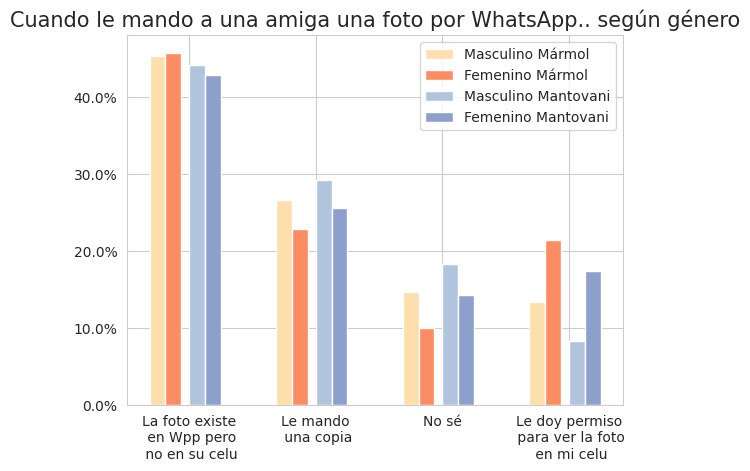

In [42]:
# Cuando le mando a una amiga una foto por WhatsApp.. - Género
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 1: "Femenino Mármol", 2: "Masculino Mantovani", 3: "Femenino Mantovani"},
                       index={"La foto ahora existe en WhatsApp y mi amiga la puede ver cuando mira nuestro chat, pero no la tiene en su celular":"La foto existe\n en Wpp pero\n no en su celu",
                              "Le mando una copia de mi foto.": "Le mando\n una copia",
                              "Le doy permiso para ver la foto que tengo guardada en mi celular.": "Le doy permiso\n para ver la foto\n en mi celu"}).fillna(0)

result = result.reindex(["La foto existe\n en Wpp pero\n no en su celu",
                         "Le mando\n una copia",
                         "No sé",
                         "Le doy permiso\n para ver la foto\n en mi celu"])

bar_width = 0.25

br1 = [1, 3, 5, 7]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Cuando le mando a una amiga una foto por WhatsApp.. según género", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('amiga_wpp_genero.png')

* Le doy permiso es un 10% más elegida en las chicas en ambos colegios.

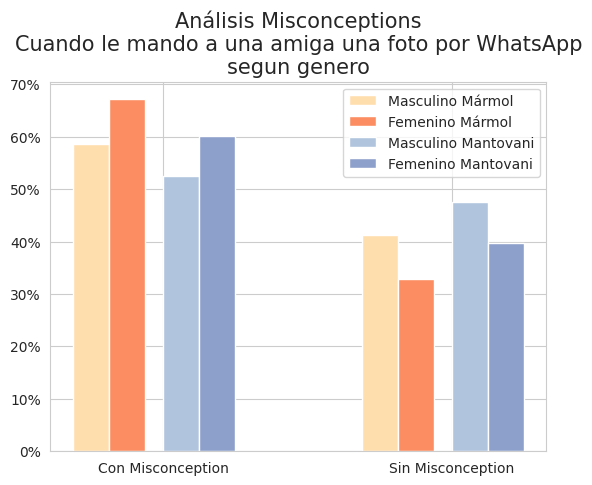

In [18]:
# Con misconception vs Sin Misconception - Agrupando No se - Cuando le mando a una amiga una foto por WhatsApp - segun genero
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 
                                1: "Femenino Mármol",
                                2: "Masculino Mantovani",
                                3: "Femenino Mantovani"},
                       index={"La foto ahora existe en WhatsApp y mi amiga la puede ver cuando mira nuestro chat, pero no la tiene en su celular":"La foto existe\n en Wpp pero\n no en su celu",
                              "Le mando una copia de mi foto.": "Le mando\n una copia",
                              "Le doy permiso para ver la foto que tengo guardada en mi celular.": "Le doy permiso\n para ver la foto\n en mi celu"}).fillna(0)

df_con_mis = result.loc[(result.index != 'No sé') & (result.index != 'Le mando\n una copia')].sum()
df_sin_mis = result.loc[(result.index == 'No sé') | (result.index == 'Le mando\n una copia')].sum()

result = pd.concat([df_con_mis, df_sin_mis], axis=1, ignore_index=True).rename(columns={0: "Con Misconception", 1: "Sin Misconception"}).transpose()

bar_width = 0.25

br1 = [1,3]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions\nCuando le mando a una amiga una foto por WhatsApp\nsegun genero", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend()
plt.savefig('misconc_agreg_amiga_wpp_genero.png')

* En ambos colegios las chicas contestan entre un 8% - 10% mas con misconception

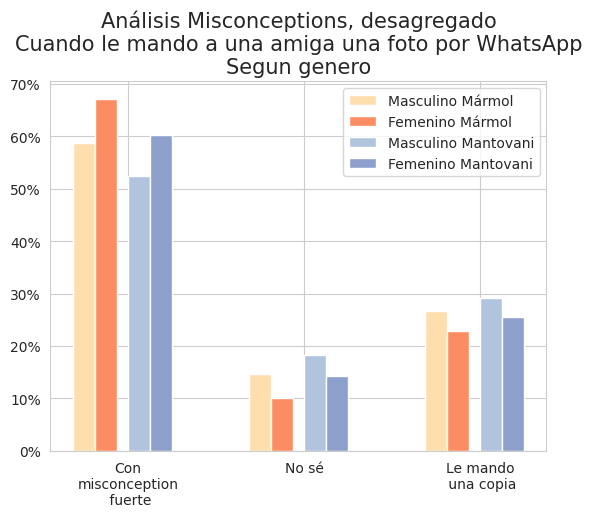

In [28]:
# Con misconception vs Sin Misconception - desagrupando No se - Cuando le mando a una amiga una foto por WhatsApp - segun genero
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 
                                1: "Femenino Mármol",
                                2: "Masculino Mantovani",
                                3: "Femenino Mantovani"},
                       index={"La foto ahora existe en WhatsApp y mi amiga la puede ver cuando mira nuestro chat, pero no la tiene en su celular":"La foto existe\n en Wpp pero\n no en su celu",
                              "Le mando una copia de mi foto.": "Le mando\n una copia",
                              "Le doy permiso para ver la foto que tengo guardada en mi celular.": "Le doy permiso\n para ver la foto\n en mi celu"}).fillna(0)

df_con_mis_fuerte = result.loc[(result.index != 'Le mando\n una copia') & 
                        (result.index != 'No sé')].sum()


result = pd.concat([ df_con_mis_fuerte, 
                     result.loc[result.index=='No sé'].sum(),
                     result.loc[result.index=='Le mando\n una copia'].sum(),
                     ], axis=1, ignore_index=True).rename(columns={0: "Con\nmisconception\n fuerte",
                                                                   1: "No sé",
                                                                   2: "Le mando\n una copia"}).transpose()

bar_width = 0.25

br1 = [1,3,5]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions, desagregado\nCuando le mando a una amiga una foto por WhatsApp\nSegun genero", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend()
plt.savefig('misconc_desagreg_amiga_wpp_genero.png')

* Desagregar el No se no modifica los resultados obtenidos anteriormente

# Si quiero hacer que mi amiga no pueda ver más la foto, ¿qué puedo hacer?

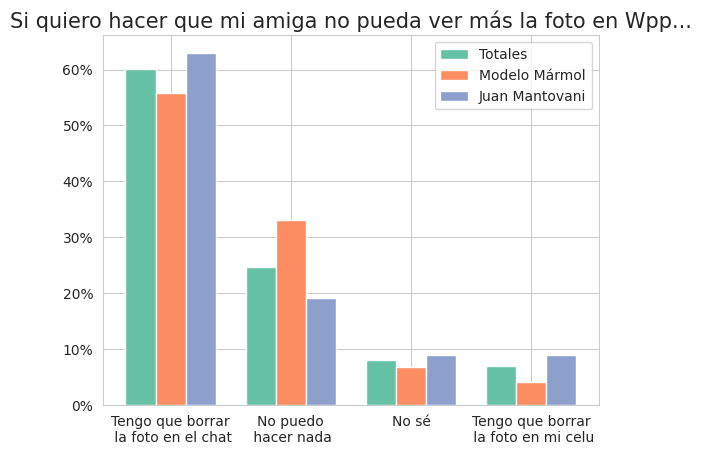

In [8]:
# Si quiero hacer que mi amiga no pueda ver más la foto, ¿qué puedo hacer?
data_total = df_fe["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"Tengo que borrar la foto en el chat.": "Tengo que borrar\n la foto en el chat",
                              "No puedo hacer nada, mi amiga ahora también tiene la foto y no tengo manera de sacársela.": "No puedo\n hacer nada",
                              "Tengo que borrar la foto en la Galería de fotos de mi celular.": "Tengo que borrar\n la foto en mi celu"}).fillna(0)

result = result.reindex(["Tengo que borrar\n la foto en el chat",
          "No puedo\n hacer nada", 
          "No sé", 
          "Tengo que borrar\n la foto en mi celu"])

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Si quiero hacer que mi amiga no pueda ver más la foto en Wpp...", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('amiga_no_ver_foto.png')

* En Mármol se elige un 10% más la respuesta "No puedo hacer nada"

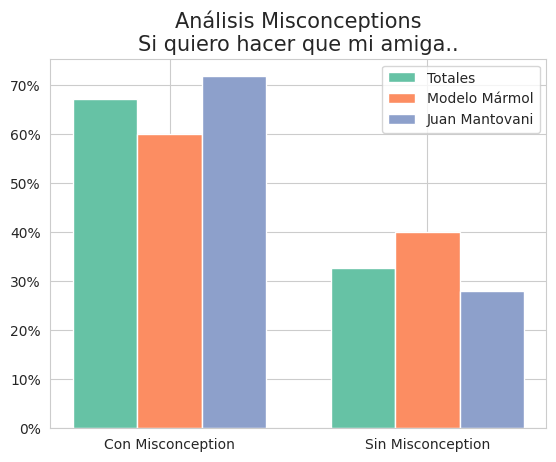

In [23]:
# Con misconception vs Sin Misconception - Agrupando No se - Si quiero hacer que mi amiga
data_total = df_fe["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"Tengo que borrar la foto en el chat.": "Tengo que borrar\n la foto en el chat",
                              "No puedo hacer nada, mi amiga ahora también tiene la foto y no tengo manera de sacársela.": "No puedo\n hacer nada",
                              "Tengo que borrar la foto en la Galería de fotos de mi celular.": "Tengo que borrar\n la foto en mi celu"}).fillna(0)

df_con_mis = result.loc[(result.index != 'No sé') & (result.index != 'No puedo\n hacer nada')].sum()
df_sin_mis = result.loc[(result.index == 'No sé') | (result.index == 'No puedo\n hacer nada')].sum()

result = pd.concat([df_con_mis, df_sin_mis], axis=1, ignore_index=True).rename(columns={0: "Con Misconception", 1: "Sin Misconception"}).transpose()

bar_width = 0.25

br1 = np.arange(len(result['Totales']))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions\nSi quiero hacer que mi amiga..", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('misconc_agreg_amiga_no_ver_foto.png')

* En el mantovani eligen un 10% mas las respuestas con misc

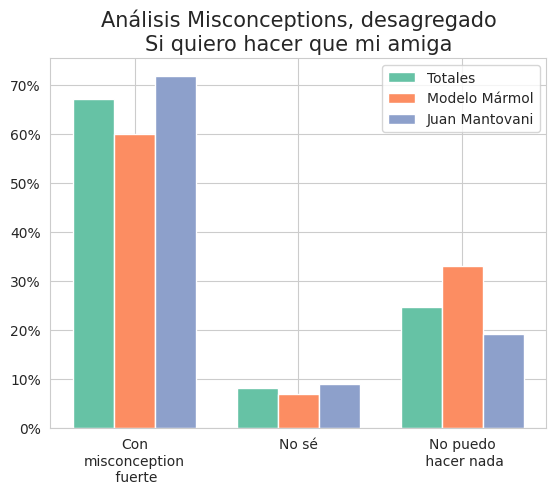

In [24]:
# Con misconception vs Sin Misconception - Desagrupando No se - Si quiero hacer que mi amiga
data_total = df_fe["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"Tengo que borrar la foto en el chat.": "Tengo que borrar\n la foto en el chat",
                              "No puedo hacer nada, mi amiga ahora también tiene la foto y no tengo manera de sacársela.": "No puedo\n hacer nada",
                              "Tengo que borrar la foto en la Galería de fotos de mi celular.": "Tengo que borrar\n la foto en mi celu"}).fillna(0)

df_con_mis_fuerte = result.loc[(result.index == 'Tengo que borrar\n la foto en el chat') |
                        (result.index == 'Tengo que borrar\n la foto en mi celu')].sum()


result = pd.concat([ df_con_mis_fuerte,
                     result.loc[result.index=='No sé'].sum(),
                     result.loc[result.index=='No puedo\n hacer nada'].sum(),
                     ], axis=1, ignore_index=True).rename(columns={0: "Con\nmisconception\n fuerte",
                                                                   1: "No sé",
                                                                   2: "No puedo\n hacer nada"}).transpose()

bar_width = 0.25

br1 = np.arange(len(result['Totales']))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions, desagregado\nSi quiero hacer que mi amiga", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('misconc_desagreg_amiga_no_ver_foto.png')

* El mantovani elige un poco mas de 10% las respuestas con misconception fuerte
* No hay diferencia en no se
* El modelo marmol elige mas de un 10% mas la opcion sin misconception no puedo hacer nada

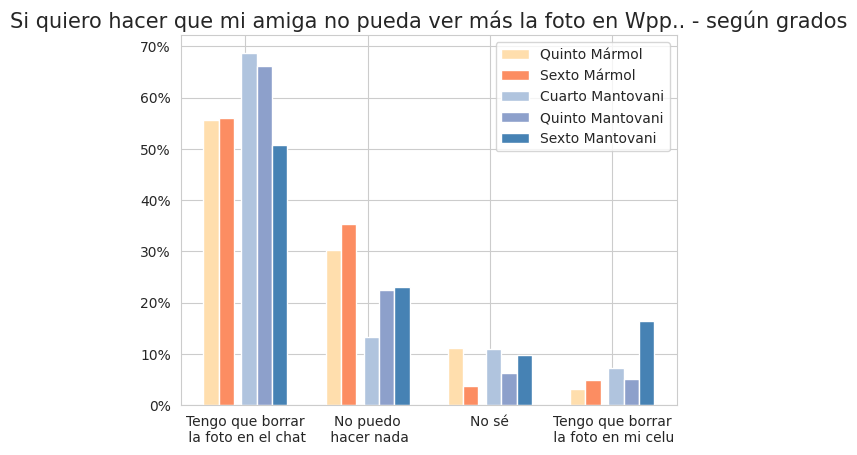

In [12]:
# Si quiero hacer que mi amiga no pueda ver más la foto, ¿qué puedo hacer? - Grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                       index={"Tengo que borrar la foto en el chat.": "Tengo que borrar\n la foto en el chat",
                              "No puedo hacer nada, mi amiga ahora también tiene la foto y no tengo manera de sacársela.": "No puedo\n hacer nada",
                              "Tengo que borrar la foto en la Galería de fotos de mi celular.": "Tengo que borrar\n la foto en mi celu"}).fillna(0)

result = result.reindex(["Tengo que borrar\n la foto en el chat",
          "No puedo\n hacer nada", 
          "No sé", 
          "Tengo que borrar\n la foto en mi celu"])

bar_width = 0.25

br1 = [1, 3, 5, 7]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Si quiero hacer que mi amiga no pueda ver más la foto en Wpp.. - según grados", fontsize=15)
plt.xticks([x + 2.25*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('amiga_no_ver_foto_grados.png')

* No hay cambios en el Modelo Mármol según grado
* En el Mantovani, de 4to a 6to baja la opcion "Tengo que borrar la foto" un 20% , sube un 10% no puedo hacer nada y sube un 10% "tengo que borrar la foto"

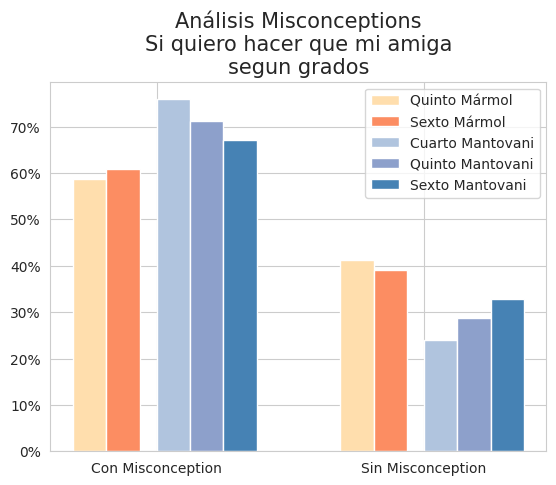

In [25]:
# Con misconception vs Sin Misconception - Agrupando No se - Si quiero hacer que mi amiga - segun grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                       index={"Tengo que borrar la foto en el chat.": "Tengo que borrar\n la foto en el chat",
                              "No puedo hacer nada, mi amiga ahora también tiene la foto y no tengo manera de sacársela.": "No puedo\n hacer nada",
                              "Tengo que borrar la foto en la Galería de fotos de mi celular.": "Tengo que borrar\n la foto en mi celu"}).fillna(0)

# print(result)

df_con_mis = result.loc[(result.index != 'No sé') & (result.index != 'No puedo\n hacer nada')].sum()
df_sin_mis = result.loc[(result.index == 'No sé') | (result.index == 'No puedo\n hacer nada')].sum()

result = pd.concat([df_con_mis, df_sin_mis], axis=1, ignore_index=True).rename(columns={0: "Con Misconception", 1: "Sin Misconception"}).transpose()

bar_width = 0.25

br1 = [1,3]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions\nSi quiero hacer que mi amiga\nsegun grados", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend()
plt.savefig('misconc_agreg_amiga_no_ver_foto_grados.png')

* Nuevamente el modelo marmol mantiene sus misconceptions en grados mas altos
* El mantovani baja levemente las respuestas con misconception en grados mas altos

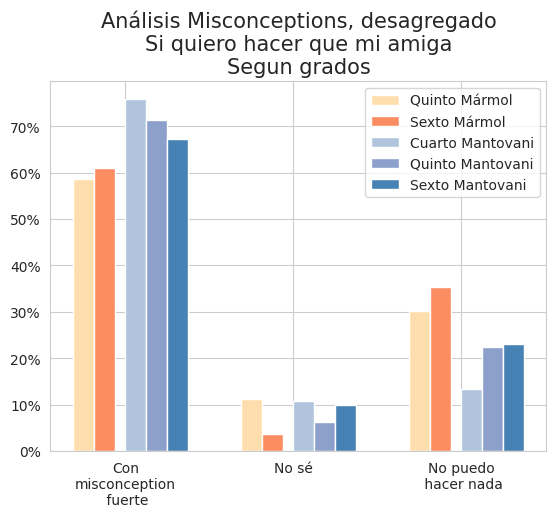

In [26]:
# Con misconception vs Sin Misconception - desagrupando No se - Si quiero hacer que mi amiga - segun grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                       index={"Tengo que borrar la foto en el chat.": "Tengo que borrar\n la foto en el chat",
                              "No puedo hacer nada, mi amiga ahora también tiene la foto y no tengo manera de sacársela.": "No puedo\n hacer nada",
                              "Tengo que borrar la foto en la Galería de fotos de mi celular.": "Tengo que borrar\n la foto en mi celu"}).fillna(0)

df_con_mis_fuerte = result.loc[(result.index != 'No puedo\n hacer nada') & 
                        (result.index != 'No sé')].sum()


result = pd.concat([ df_con_mis_fuerte,
                     result.loc[result.index=='No sé'].sum(),
                     result.loc[result.index=='No puedo\n hacer nada'].sum(),
                     ], axis=1, ignore_index=True).rename(columns={0: "Con\nmisconception\n fuerte",
                                                                   1: "No sé",
                                                                   2: "No puedo\n hacer nada"}).transpose()

bar_width = 0.25

br1 = [1,3,5]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions, desagregado\nSi quiero hacer que mi amiga\nSegun grados", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend()
plt.savefig('misconc_desagreg_amiga_no_ver_foto_grados.png')

* En el marmol suben levemente las misc fuertes, baja mas de un 5% el no se (como en otras respuestas) y sube levemente la respuesta sin misconc. Con lo cual la diferencia entre 5to y 6to es que eligen menos no se y mas las otras respuestas
* En el mantovani bajan las misconception fuertes y aumentan las respuetas sin misc

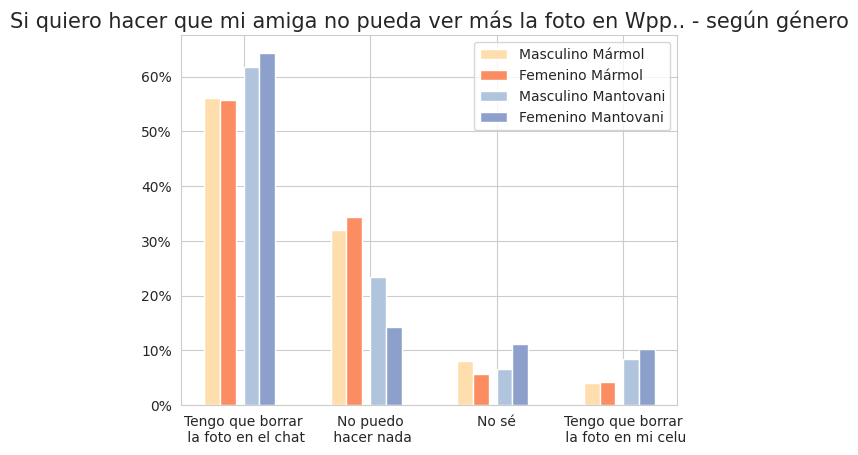

In [13]:
# Si quiero hacer que mi amiga no pueda ver más la foto, ¿qué puedo hacer? - Género
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 1: "Femenino Mármol", 2: "Masculino Mantovani", 3: "Femenino Mantovani"},
                       index={"Tengo que borrar la foto en el chat.": "Tengo que borrar\n la foto en el chat",
                              "No puedo hacer nada, mi amiga ahora también tiene la foto y no tengo manera de sacársela.": "No puedo\n hacer nada",
                              "Tengo que borrar la foto en la Galería de fotos de mi celular.": "Tengo que borrar\n la foto en mi celu"}).fillna(0)

result = result.reindex(["Tengo que borrar\n la foto en el chat",
          "No puedo\n hacer nada", 
          "No sé", 
          "Tengo que borrar\n la foto en mi celu"])

bar_width = 0.25

br1 = [1, 3, 5, 7]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Si quiero hacer que mi amiga no pueda ver más la foto en Wpp.. - según género", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('amiga_no_ver_foto_genero.png')

* No hay grandes diferencias en el Mármol
* En el mantovani las chicas eligen un 10% menos No puedo hacer nada

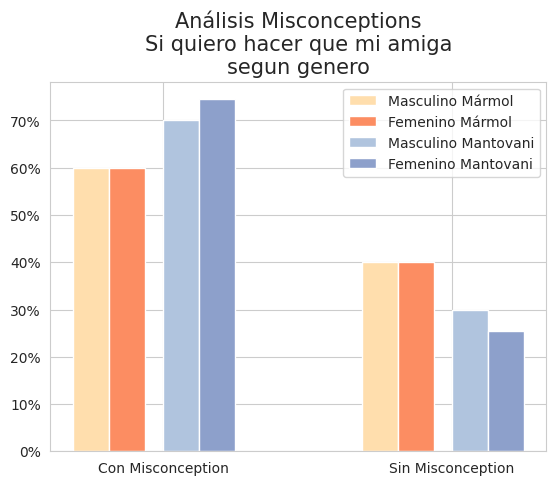

In [27]:
# Con misconception vs Sin Misconception - Agrupando No se - Si quiero hacer que mi amiga - segun genero
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 
                                1: "Femenino Mármol",
                                2: "Masculino Mantovani",
                                3: "Femenino Mantovani"},
                       index={"Tengo que borrar la foto en el chat.": "Tengo que borrar\n la foto en el chat",
                              "No puedo hacer nada, mi amiga ahora también tiene la foto y no tengo manera de sacársela.": "No puedo\n hacer nada",
                              "Tengo que borrar la foto en la Galería de fotos de mi celular.": "Tengo que borrar\n la foto en mi celu"}).fillna(0)

df_con_mis = result.loc[(result.index != 'No sé') & (result.index != 'No puedo\n hacer nada')].sum()
df_sin_mis = result.loc[(result.index == 'No sé') | (result.index == 'No puedo\n hacer nada')].sum()

result = pd.concat([df_con_mis, df_sin_mis], axis=1, ignore_index=True).rename(columns={0: "Con Misconception", 1: "Sin Misconception"}).transpose()

bar_width = 0.25

br1 = [1,3]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions\nSi quiero hacer que mi amiga\nsegun genero", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend()
plt.savefig('misconc_agreg_amiga_no_ver_foto_genero.png')

* No hay diferencia en marmol
* En el mantovani las chicas eligen cerca de un 5% mas las respuestas con misc

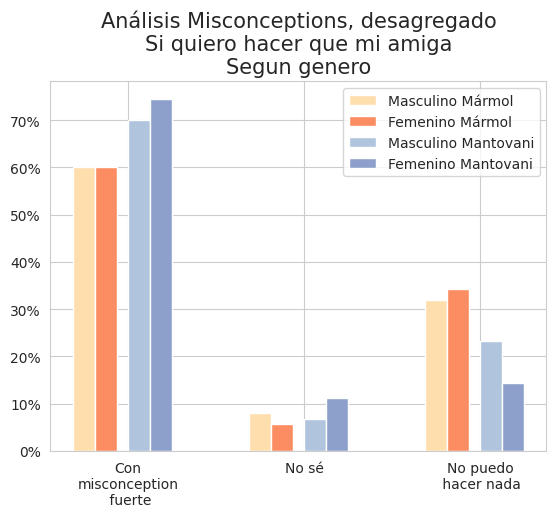

In [30]:
# Con misconception vs Sin Misconception - desagrupando No se - Si quiero hacer que mi amiga - segun genero
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 
                                1: "Femenino Mármol",
                                2: "Masculino Mantovani",
                                3: "Femenino Mantovani"},
                       index={"Tengo que borrar la foto en el chat.": "Tengo que borrar\n la foto en el chat",
                              "No puedo hacer nada, mi amiga ahora también tiene la foto y no tengo manera de sacársela.": "No puedo\n hacer nada",
                              "Tengo que borrar la foto en la Galería de fotos de mi celular.": "Tengo que borrar\n la foto en mi celu"}).fillna(0)

df_con_mis_fuerte = result.loc[(result.index != 'No puedo\n hacer nada') & 
                        (result.index != 'No sé')].sum()


result = pd.concat([ df_con_mis_fuerte, 
                     result.loc[result.index=='No sé'].sum(),
                     result.loc[result.index=='No puedo\n hacer nada'].sum(),
                     ], axis=1, ignore_index=True).rename(columns={0: "Con\nmisconception\n fuerte",
                                                                   1: "No sé",
                                                                   2: "No puedo\n hacer nada"}).transpose()

bar_width = 0.25

br1 = [1,3,5]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions, desagregado\nSi quiero hacer que mi amiga\nSegun genero", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend()
plt.savefig('misconc_desagreg_amiga_no_ver_foto_genero.png')

* No hay diferencias notables en el Marmol
* En el Mantovani las chicas eligen un 5% mas respuestas con misconceptions fuertes. Tambien eligen mas la respuesta "No se" y Menos la respuesta sin misconception

# ¿Cómo viaja un mensaje de Wpp sin Wi-Fi?

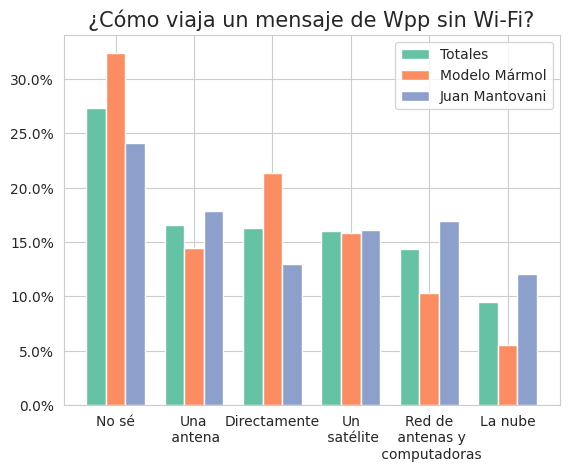

In [18]:
# ¿Cómo viaja un mensaje de Wpp sin Wi-Fi?
data_total = df_fe["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"El mensaje se manda a través de una antena.": "Una\n antena",
                              "El mensaje se manda directamente.": "Directamente",
                              "El mensaje se manda a través de un satélite.": "Un\n satélite",
                              "El mensaje se manda a través de una red de antenas y computadoras.": "Red de\n antenas y\n computadoras",
                              "El mensaje se manda a través de la nube.": "La nube"}).fillna(0)

result = result.reindex(["No sé", "Una\n antena", "Directamente", "Un\n satélite", "Red de\n antenas y\n computadoras", "La nube"])

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("¿Cómo viaja un mensaje de Wpp sin Wi-Fi?", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('como_viaja_wpp.png')

* En Mármol se eligen un 15% más la opción No sey la opción Directamente.
* En Mantovani se eligen un 15% más la opción "Red de antenas y computadoras" y "la nube"

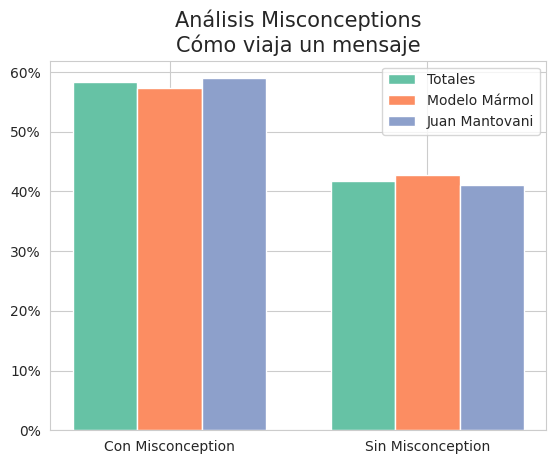

In [4]:
# Con misconception vs Sin Misconception - Agrupando No se - Cómo viaja un mensaje
data_total = df_fe["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"El mensaje se manda a través de una antena.": "Una\n antena",
                              "El mensaje se manda directamente.": "Directamente",
                              "El mensaje se manda a través de un satélite.": "Un\n satélite",
                              "El mensaje se manda a través de una red de antenas y computadoras.": "Red de\n antenas y\n computadoras",
                              "El mensaje se manda a través de la nube.": "La nube"}).fillna(0)

df_con_mis = result.loc[(result.index != 'No sé') & (result.index != 'Red de\n antenas y\n computadoras')].sum()
df_sin_mis = result.loc[(result.index == 'No sé') | (result.index == 'Red de\n antenas y\n computadoras')].sum()

result = pd.concat([df_con_mis, df_sin_mis], axis=1, ignore_index=True).rename(columns={0: "Con Misconception", 1: "Sin Misconception"}).transpose()

bar_width = 0.25

br1 = np.arange(len(result['Totales']))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions\nCómo viaja un mensaje", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('misconc_agreg_como_viaja_wpp.png')

* Ambos colegios tienen porcentajes similares de Misconceptions

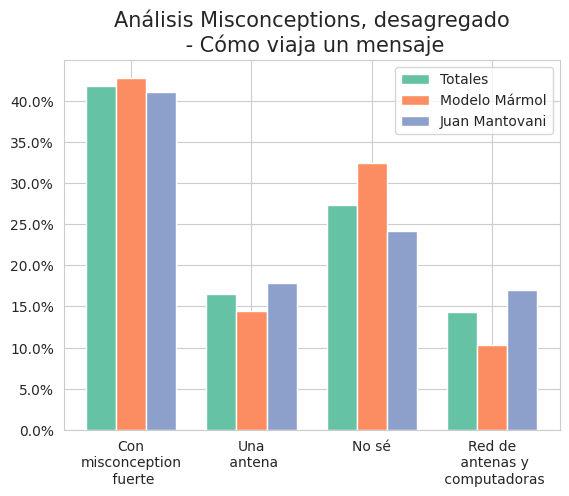

In [5]:
# Con misconception vs Sin Misconception - Agrupando No se - Cómo viaja un mensaje
data_total = df_fe["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"El mensaje se manda a través de una antena.": "Una\n antena",
                              "El mensaje se manda directamente.": "Directamente",
                              "El mensaje se manda a través de un satélite.": "Un\n satélite",
                              "El mensaje se manda a través de una red de antenas y computadoras.": "Red de\n antenas y\n computadoras",
                              "El mensaje se manda a través de la nube.": "La nube"}).fillna(0)

df_con_mis_fuerte = result.loc[(result.index != 'Red de\n antenas y\n computadoras') & 
                        (result.index != 'No sé') & 
                        (result.index != 'Una\n antena')].sum()


result = pd.concat([ df_con_mis_fuerte, 
                     result.loc[result.index=='Una\n antena'].sum(),
                     result.loc[result.index=='No sé'].sum(),
                     result.loc[result.index=='Red de\n antenas y\n computadoras'].sum(),
                     ], axis=1, ignore_index=True).rename(columns={0: "Con\nmisconception\n fuerte",
                                                                   1: "Una\n antena",
                                                                   2: "No sé",
                                                                   3: "Red de\n antenas y\n computadoras"}).transpose()

bar_width = 0.25

br1 = np.arange(len(result['Totales']))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions, desagregado\n - Cómo viaja un mensaje", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('misconc_desagreg_como_viaja_wpp.png')

* En el modelo se elige mas no se
* en el mantovani se elige mas la respuesta sin misconception

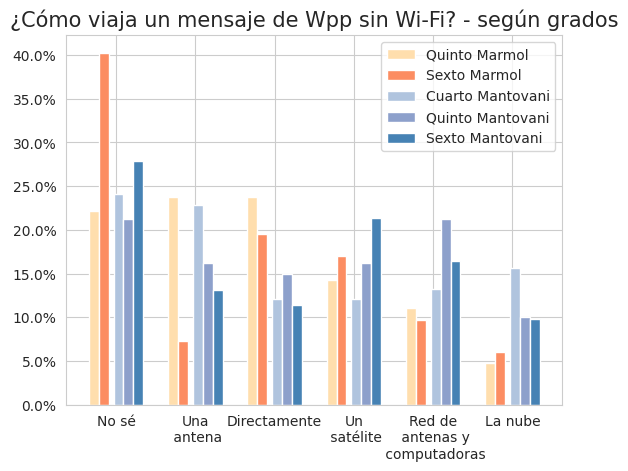

In [19]:
# ¿Cómo viaja un mensaje de Wpp sin Wi-Fi? - Grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Marmol',
                                1:'Sexto Marmol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                       index={"El mensaje se manda a través de una antena.": "Una\n antena",
                              "El mensaje se manda directamente.": "Directamente",
                              "El mensaje se manda a través de un satélite.": "Un\n satélite",
                              "El mensaje se manda a través de una red de antenas y computadoras.": "Red de\n antenas y\n computadoras",
                              "El mensaje se manda a través de la nube.": "La nube"}).fillna(0)

result = result.reindex(["No sé", "Una\n antena", "Directamente", "Un\n satélite", "Red de\n antenas y\n computadoras", "La nube"])

br1 = [1, 3, 5, 7, 9, 11]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Marmol']    , width=bar_width, label = 'Quinto Marmol', color='navajowhite')
plt.bar(br2, result['Sexto Marmol']     , width=bar_width, label = 'Sexto Marmol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("¿Cómo viaja un mensaje de Wpp sin Wi-Fi? - según grados", fontsize=15)
plt.xticks([x + 2.25*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('como_viaja_wpp_grados.png')

* En el Mármol el 6to gradoelige un 20% más la opción "No sé" que 5to y un 20% menos la opción "una antena"
* En el Mantovani, de 4to a 6to, baja un 10% la respuesta "Una antena", sube un 10% "Un satélite" y sube la respuesta "Red de antenas y compus" un 10% en 5to y luego baja en 6to.

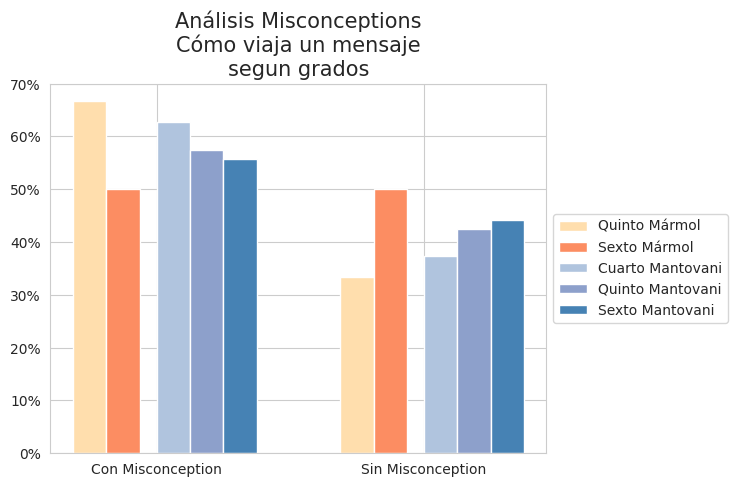

In [7]:
# Con misconception vs Sin Misconception - Agrupando No se - Cómo viaja un mensaje - segun grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                       index={"El mensaje se manda a través de una antena.": "Una\n antena",
                              "El mensaje se manda directamente.": "Directamente",
                              "El mensaje se manda a través de un satélite.": "Un\n satélite",
                              "El mensaje se manda a través de una red de antenas y computadoras.": "Red de\n antenas y\n computadoras",
                              "El mensaje se manda a través de la nube.": "La nube"}).fillna(0)

# print(result)

df_con_mis = result.loc[(result.index != 'No sé') & (result.index != 'Red de\n antenas y\n computadoras')].sum()
df_sin_mis = result.loc[(result.index == 'No sé') | (result.index == 'Red de\n antenas y\n computadoras')].sum()

result = pd.concat([df_con_mis, df_sin_mis], axis=1, ignore_index=True).rename(columns={0: "Con Misconception", 1: "Sin Misconception"}).transpose()

bar_width = 0.25

br1 = [1,3]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions\nCómo viaja un mensaje\nsegun grados", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig('misconc_agreg_como_viaja_wpp_grados.png')

* En grados mas altos, ambos colegios bajan la misconception

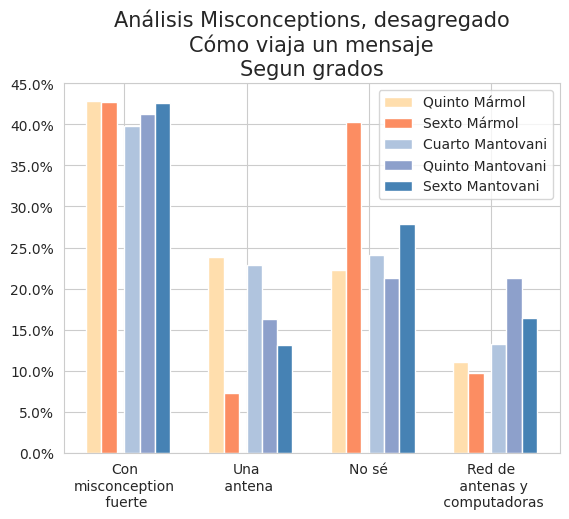

In [8]:
# Con misconception vs Sin Misconception - desagrupando No se - Cómo viaja un mensaje - segun grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                       index={"El mensaje se manda a través de una antena.": "Una\n antena",
                              "El mensaje se manda directamente.": "Directamente",
                              "El mensaje se manda a través de un satélite.": "Un\n satélite",
                              "El mensaje se manda a través de una red de antenas y computadoras.": "Red de\n antenas y\n computadoras",
                              "El mensaje se manda a través de la nube.": "La nube"}).fillna(0)

df_con_mis_fuerte = result.loc[(result.index != 'Red de\n antenas y\n computadoras') & 
                        (result.index != 'No sé') &
                        (result.index != 'Una\n antena')].sum()


result = pd.concat([ df_con_mis_fuerte,
                     result.loc[result.index=='Una\n antena'].sum(),
                     result.loc[result.index=='No sé'].sum(),
                     result.loc[result.index=='Red de\n antenas y\n computadoras'].sum(),
                     ], axis=1, ignore_index=True).rename(columns={0: "Con\nmisconception\n fuerte",
                                                                   1: "Una\n antena",
                                                                   2: "No sé",
                                                                   3: "Red de\n antenas y\n computadoras"}).transpose()

bar_width = 0.25

br1 = [1,3,5,7]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions, desagregado\nCómo viaja un mensaje\nSegun grados", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend()
plt.savefig('misconc_desagreg_como_viaja_wpp_grados.png')

* En marmol se selecciona menos la misconception debil una antena y se elige mas "no se" en 6to grado
* En el mantovani baja considerablemente la misconception debil una antena y se aumenta levemente las respuestas no se y red de antenas y compus

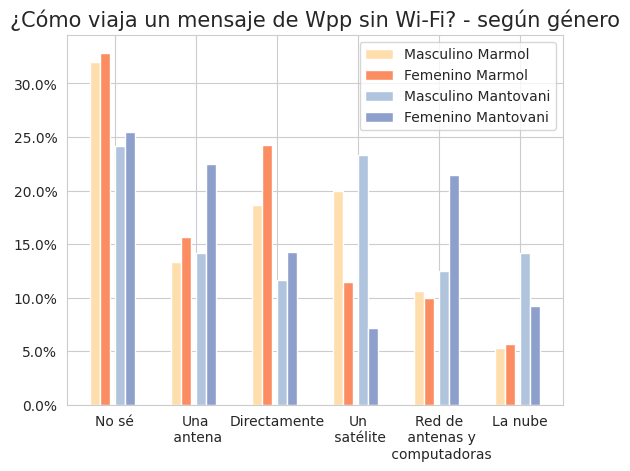

In [20]:
# ¿Cómo viaja un mensaje de Wpp sin Wi-Fi? - Género
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Marmol", 1: "Femenino Marmol", 2: "Masculino Mantovani", 3: "Femenino Mantovani"},
                       index={"El mensaje se manda a través de una antena.": "Una\n antena",
                              "El mensaje se manda directamente.": "Directamente",
                              "El mensaje se manda a través de un satélite.": "Un\n satélite",
                              "El mensaje se manda a través de una red de antenas y computadoras.": "Red de\n antenas y\n computadoras",
                              "El mensaje se manda a través de la nube.": "La nube"}).fillna(0)

result = result.reindex(["No sé", "Una\n antena", "Directamente", "Un\n satélite", "Red de\n antenas y\n computadoras", "La nube"])

bar_width = 0.25

br1 = [1, 3, 5, 7, 9 , 11]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Marmol"],     width=bar_width, label = 'Masculino Marmol', color='navajowhite')
plt.bar(br2,result["Femenino Marmol"],      width=bar_width, label = 'Femenino Marmol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("¿Cómo viaja un mensaje de Wpp sin Wi-Fi? - según género", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('como_viaja_wpp_genero.png')

* En ambos colegios los chicos eligen arriba de un 10% más la opción "Un satélite".
* Marmol: Las chicas eligen un 5% más la opción directamente.
* Mantovani: Las chicas eligen un 5% más "Una antena". Los chicos eligen un 20% más un satélite. También las chicas eligen un 10% más la opción correcta, "Red de antenas y compus". Y los chicos un 5% más La nube.

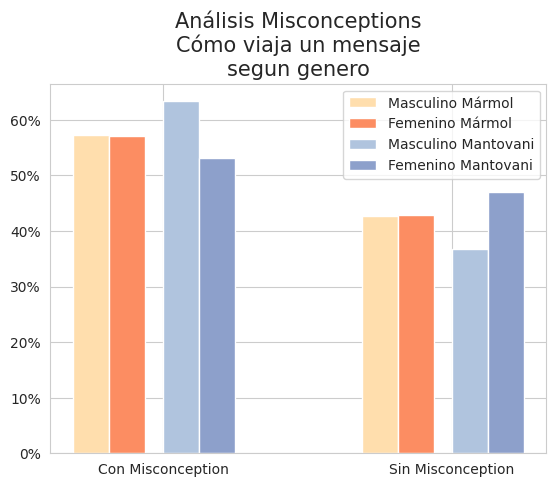

In [9]:
# Con misconception vs Sin Misconception - desagrupando No se - Cómo viaja un mensaje - segun genero
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 
                                1: "Femenino Mármol",
                                2: "Masculino Mantovani",
                                3: "Femenino Mantovani"},
                       index={"El mensaje se manda a través de una antena.": "Una\n antena",
                              "El mensaje se manda directamente.": "Directamente",
                              "El mensaje se manda a través de un satélite.": "Un\n satélite",
                              "El mensaje se manda a través de una red de antenas y computadoras.": "Red de\n antenas y\n computadoras",
                              "El mensaje se manda a través de la nube.": "La nube"}).fillna(0)

df_con_mis = result.loc[(result.index != 'No sé') & (result.index != 'Red de\n antenas y\n computadoras')].sum()
df_sin_mis = result.loc[(result.index == 'No sé') | (result.index == 'Red de\n antenas y\n computadoras')].sum()

result = pd.concat([df_con_mis, df_sin_mis], axis=1, ignore_index=True).rename(columns={0: "Con Misconception", 1: "Sin Misconception"}).transpose()

bar_width = 0.25

br1 = [1,3]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions\nCómo viaja un mensaje\nsegun genero", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend()
plt.savefig('misconc_agreg_como_viaja_wpp_genero.png')

* No hay diferencias en el Marmol
* Los varones responden un 10% mas con misconception

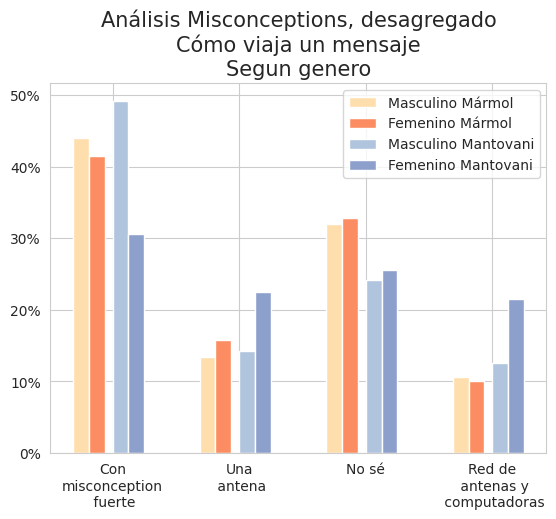

In [10]:
# Con misconception vs Sin Misconception - desagrupando No se - Cómo viaja un mensaje - segun genero
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 
                                1: "Femenino Mármol",
                                2: "Masculino Mantovani",
                                3: "Femenino Mantovani"},
                       index={"El mensaje se manda a través de una antena.": "Una\n antena",
                              "El mensaje se manda directamente.": "Directamente",
                              "El mensaje se manda a través de un satélite.": "Un\n satélite",
                              "El mensaje se manda a través de una red de antenas y computadoras.": "Red de\n antenas y\n computadoras",
                              "El mensaje se manda a través de la nube.": "La nube"}).fillna(0)

df_con_mis_fuerte = result.loc[(result.index != 'Red de\n antenas y\n computadoras') & 
                        (result.index != 'No sé') &
                        (result.index != 'Una\n antena')].sum()


result = pd.concat([ df_con_mis_fuerte, 
                     result.loc[result.index=='Una\n antena'].sum(),
                     result.loc[result.index=='No sé'].sum(),
                     result.loc[result.index=='Red de\n antenas y\n computadoras'].sum(),
                     ], axis=1, ignore_index=True).rename(columns={0: "Con\nmisconception\n fuerte",
                                                                   1: "Una\n antena",
                                                                   2: "No sé",
                                                                   3: "Red de\n antenas y\n computadoras"}).transpose()

bar_width = 0.25

br1 = [1,3,5,7]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions, desagregado\nCómo viaja un mensaje\nSegun genero", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend()
plt.savefig('misconc_desagreg_como_viaja_wpp_genero.png')

* En el marmol no hay mucha diferencia
* En el mantovani Las chicas responden un 20% menos con misconception fuerte, tambien Responden un 10% mas la misconception debil: una antena. Adicionalmente responden un 10% mas la respuesta sin misconception.

# Si me llega un mensaje por WhatsApp con un link para descargar una aplicación, ¿cuál de las siguientes opciones creés que es la correcta?

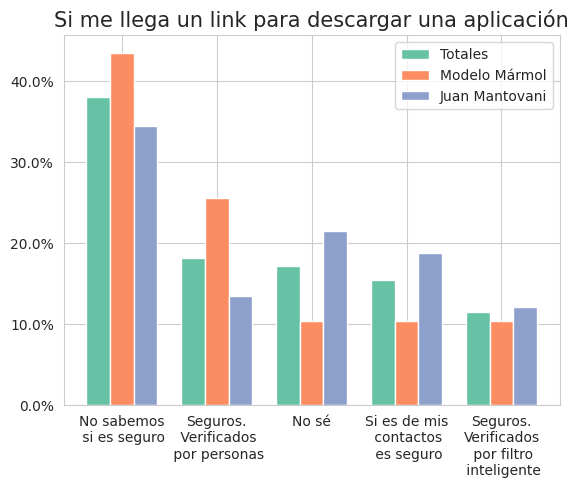

In [25]:
# Si me llega un mensaje por WhatsApp con un link para descargar una aplicación
data_total = df_fe["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"Los mensajes recibidos no están verificados de ninguna forma. No podemos saber si el link es seguro.": "No sabemos\n si es seguro",
                              "Los mensajes recibidos están verificados por personas en WhatsApp. El link es seguro.": "Seguros.\n Verificados\n por personas",
                              "No sé.": "No sé",
                              "Si el mensaje fue enviado por uno de mis contactos entonces el link es seguro.": "Si es de mis\n contactos\n es seguro",
                              "Los mensajes recibidos están verificados por un filtro inteligente. El link es seguro.": "Seguros.\nVerificados\n por filtro\n inteligente"}).fillna(0)

result = result.reindex(["No sabemos\n si es seguro", "Seguros.\n Verificados\n por personas", "No sé", "Si es de mis\n contactos\n es seguro", "Seguros.\nVerificados\n por filtro\n inteligente"])

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Si me llega un link para descargar una aplicación", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('link_descarga.png')

* Mármol elige un 10% más "No sabemos si es seguro" y "verificados por personas"
* Mantovani elige 10% más "No se" y "Si es de mis contactos es seguro". 

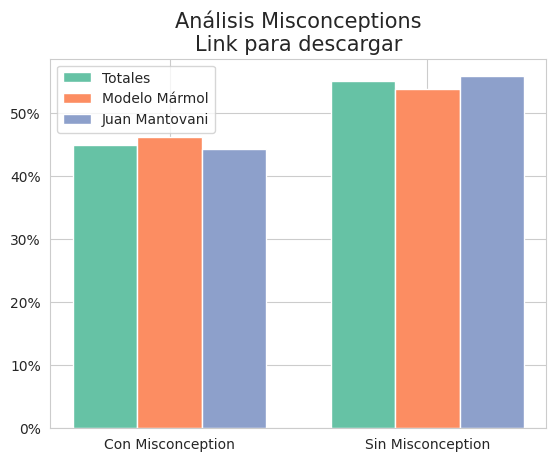

In [11]:
# Con misconception vs Sin Misconception - Agrupando No se - link para descargar
data_total = df_fe["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"Los mensajes recibidos no están verificados de ninguna forma. No podemos saber si el link es seguro.": "No sabemos\n si es seguro",
                              "Los mensajes recibidos están verificados por personas en WhatsApp. El link es seguro.": "Seguros.\n Verificados\n por personas",
                              "No sé.": "No sé",
                              "Si el mensaje fue enviado por uno de mis contactos entonces el link es seguro.": "Si es de mis\n contactos\n es seguro",
                              "Los mensajes recibidos están verificados por un filtro inteligente. El link es seguro.": "Seguros.\nVerificados\n por filtro\n inteligente"}).fillna(0)

df_con_mis = result.loc[(result.index != 'No sé') & (result.index != 'No sabemos\n si es seguro')].sum()
df_sin_mis = result.loc[(result.index == 'No sé') | (result.index == 'No sabemos\n si es seguro')].sum()

result = pd.concat([df_con_mis, df_sin_mis], axis=1, ignore_index=True).rename(columns={0: "Con Misconception", 1: "Sin Misconception"}).transpose()

bar_width = 0.25

br1 = np.arange(len(result['Totales']))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions\nLink para descargar", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('misconc_agreg_link_descarga.png')

* En ambos colegios vemos "Sin misconception" por encima de con misconception por primera vez

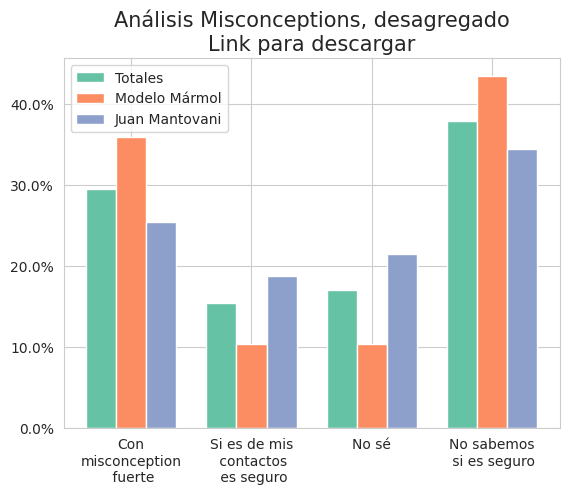

In [13]:
# Con misconception vs Sin Misconception - Desagrupando No se - Link para descargar
data_total = df_fe["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"Los mensajes recibidos no están verificados de ninguna forma. No podemos saber si el link es seguro.": "No sabemos\n si es seguro",
                              "Los mensajes recibidos están verificados por personas en WhatsApp. El link es seguro.": "Seguros.\n Verificados\n por personas",
                              "No sé.": "No sé",
                              "Si el mensaje fue enviado por uno de mis contactos entonces el link es seguro.": "Si es de mis\n contactos\n es seguro",
                              "Los mensajes recibidos están verificados por un filtro inteligente. El link es seguro.": "Seguros.\nVerificados\n por filtro\n inteligente"}).fillna(0)

df_con_mis_fuerte = result.loc[(result.index == 'Seguros.\n Verificados\n por personas') |
                        (result.index == 'Seguros.\nVerificados\n por filtro\n inteligente')].sum()


result = pd.concat([ df_con_mis_fuerte,
                     result.loc[result.index=='Si es de mis\n contactos\n es seguro'].sum(),
                     result.loc[result.index=='No sé'].sum(),
                     result.loc[result.index=='No sabemos\n si es seguro'].sum(),
                     ], axis=1, ignore_index=True).rename(columns={0: "Con\nmisconception\n fuerte",
                                                                   1: "Si es de mis\n contactos\n es seguro",
                                                                   2: "No sé",
                                                                   3: "No sabemos\n si es seguro"}).transpose()

bar_width = 0.25

br1 = np.arange(len(result['Totales']))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions, desagregado\nLink para descargar", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('misconc_desagreg_link_descarga.png')

* Modelo marmol con mas misconceptions que el mantovani
* El mantovani elige mas la misconception debil
* EL mantovani elige mas No se
* El modelo Marmol elige mas la respuesta sin miscon

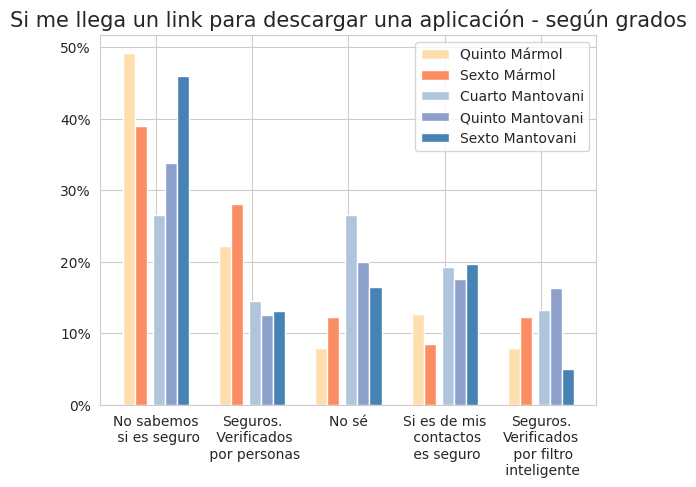

In [26]:
# Si me llega un link para descargar una aplicación - Grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                       index={"Los mensajes recibidos no están verificados de ninguna forma. No podemos saber si el link es seguro.": "No sabemos\n si es seguro",
                              "Los mensajes recibidos están verificados por personas en WhatsApp. El link es seguro.": "Seguros.\n Verificados\n por personas",
                              "No sé.": "No sé",
                              "Si el mensaje fue enviado por uno de mis contactos entonces el link es seguro.": "Si es de mis\n contactos\n es seguro",
                              "Los mensajes recibidos están verificados por un filtro inteligente. El link es seguro.": "Seguros.\nVerificados\n por filtro\n inteligente"}).fillna(0)

result = result.reindex(["No sabemos\n si es seguro", "Seguros.\n Verificados\n por personas", "No sé", "Si es de mis\n contactos\n es seguro", "Seguros.\nVerificados\n por filtro\n inteligente"])

br1 = [1, 3, 5, 7, 9]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Si me llega un link para descargar una aplicación - según grados", fontsize=15)
plt.xticks([x + 2.25*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('link_descarga_grados.png')

* Modelo Mármol: 6to elige un 10% menos "No sabemos si es seguro" y un 5% más "Verificados por personas"
* Mantovani: De 4to a 6to sube un 20% "No sabemos si es seguro", baja un 10% la opción "No sé" y un 10% "Verificados por filtro inteligente"

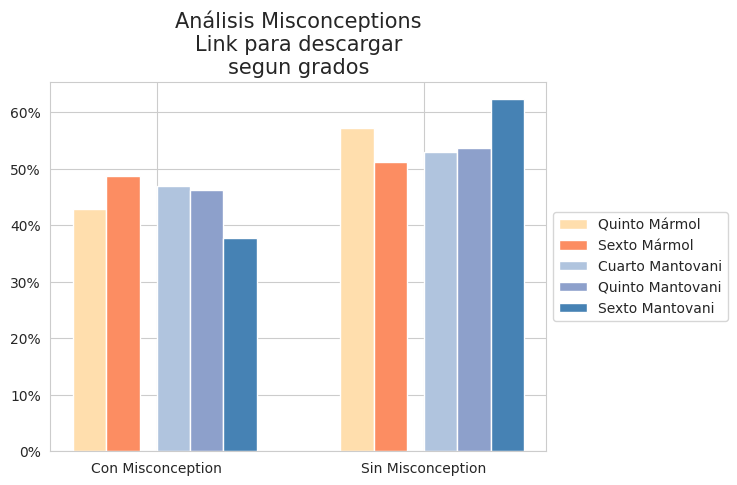

In [15]:
# Con misconception vs Sin Misconception - Agrupando No se - link para descargar  - segun grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                       index={"Los mensajes recibidos no están verificados de ninguna forma. No podemos saber si el link es seguro.": "No sabemos\n si es seguro",
                              "Los mensajes recibidos están verificados por personas en WhatsApp. El link es seguro.": "Seguros.\n Verificados\n por personas",
                              "No sé.": "No sé",
                              "Si el mensaje fue enviado por uno de mis contactos entonces el link es seguro.": "Si es de mis\n contactos\n es seguro",
                              "Los mensajes recibidos están verificados por un filtro inteligente. El link es seguro.": "Seguros.\nVerificados\n por filtro\n inteligente"}).fillna(0)

# print(result)

df_con_mis = result.loc[(result.index != 'No sé') & (result.index != 'No sabemos\n si es seguro')].sum()
df_sin_mis = result.loc[(result.index == 'No sé') | (result.index == 'No sabemos\n si es seguro')].sum()

result = pd.concat([df_con_mis, df_sin_mis], axis=1, ignore_index=True).rename(columns={0: "Con Misconception", 1: "Sin Misconception"}).transpose()

bar_width = 0.25

br1 = [1,3]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions\nLink para descargar\nsegun grados", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig('misconc_agreg_link_descarga_grados.png')

* EN el modelo en 6to grado aumentan misconceptions
* En el mantovani reducen misconceptions

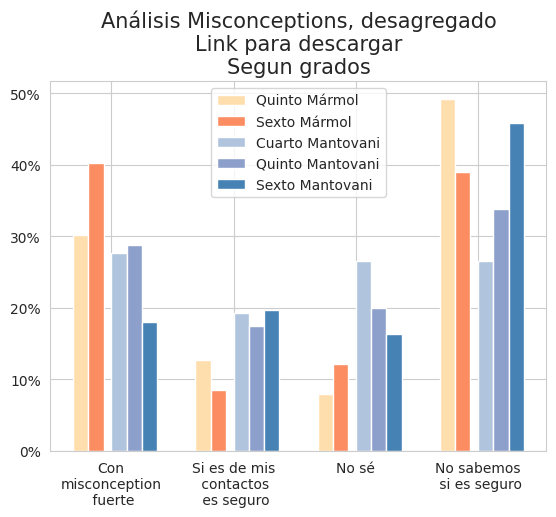

In [16]:
# Con misconception vs Sin Misconception - desagrupando No se - Link para descargar - segun grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                       index={"Los mensajes recibidos no están verificados de ninguna forma. No podemos saber si el link es seguro.": "No sabemos\n si es seguro",
                              "Los mensajes recibidos están verificados por personas en WhatsApp. El link es seguro.": "Seguros.\n Verificados\n por personas",
                              "No sé.": "No sé",
                              "Si el mensaje fue enviado por uno de mis contactos entonces el link es seguro.": "Si es de mis\n contactos\n es seguro",
                              "Los mensajes recibidos están verificados por un filtro inteligente. El link es seguro.": "Seguros.\nVerificados\n por filtro\n inteligente"}).fillna(0)

df_con_mis_fuerte = result.loc[(result.index == 'Seguros.\n Verificados\n por personas') |
                        (result.index == 'Seguros.\nVerificados\n por filtro\n inteligente')].sum()


result = pd.concat([ df_con_mis_fuerte,
                     result.loc[result.index=='Si es de mis\n contactos\n es seguro'].sum(),
                     result.loc[result.index=='No sé'].sum(),
                     result.loc[result.index=='No sabemos\n si es seguro'].sum(),
                     ], axis=1, ignore_index=True).rename(columns={0: "Con\nmisconception\n fuerte",
                                                                   1: "Si es de mis\n contactos\n es seguro",
                                                                   2: "No sé",
                                                                   3: "No sabemos\n si es seguro"}).transpose()

bar_width = 0.25

br1 = [1,3,5,7]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions, desagregado\nLink para descargar\nSegun grados", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend()
plt.savefig('misconc_desagreg_link_descarga_grados.png')

* Modelo: Sexto tiene un 10% mas de respuestas con misconc fuertes, elige menos la rta con misconc debil, eligen mas No se y 10% menos la rta sin misc
* Mantovani: En grados mas altos bajan misconceptions, bajan no se y aumentan la rta sin misconc. Un lujo

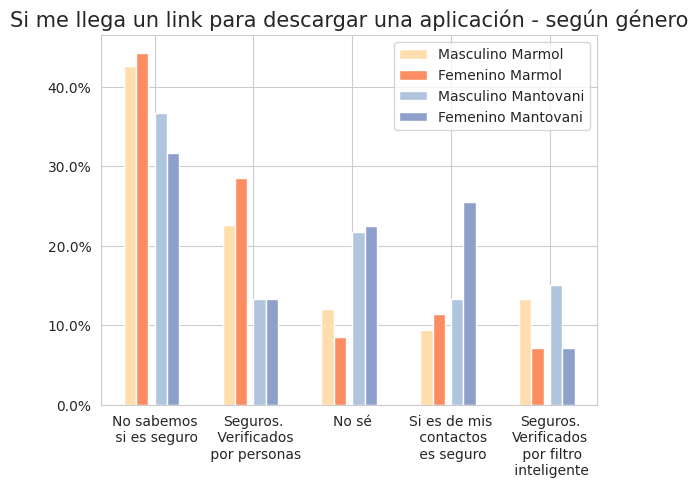

In [27]:
# Si me llega un link para descargar una aplicación - Género
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Marmol", 1: "Femenino Marmol", 2: "Masculino Mantovani", 3: "Femenino Mantovani"},
                       index={"Los mensajes recibidos no están verificados de ninguna forma. No podemos saber si el link es seguro.": "No sabemos\n si es seguro",
                              "Los mensajes recibidos están verificados por personas en WhatsApp. El link es seguro.": "Seguros.\n Verificados\n por personas",
                              "No sé.": "No sé",
                              "Si el mensaje fue enviado por uno de mis contactos entonces el link es seguro.": "Si es de mis\n contactos\n es seguro",
                              "Los mensajes recibidos están verificados por un filtro inteligente. El link es seguro.": "Seguros.\nVerificados\n por filtro\n inteligente"}).fillna(0)

result = result.reindex(["No sabemos\n si es seguro", "Seguros.\n Verificados\n por personas", "No sé", "Si es de mis\n contactos\n es seguro", "Seguros.\nVerificados\n por filtro\n inteligente"])

bar_width = 0.25

br1 = [1, 3, 5, 7, 9]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Marmol"],     width=bar_width, label = 'Masculino Marmol', color='navajowhite')
plt.bar(br2,result["Femenino Marmol"],      width=bar_width, label = 'Femenino Marmol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Si me llega un link para descargar una aplicación - según género", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('link_descarga_genero.png')

* No hay muchas diferencias en el Mármol, las chicas eligen un 5% más la opción "Verificados por personas", y los varones un 5% más "Verificados por filtro inteligente"
* En el Mantovani las chicas eligen un 15% más "Si es de mis contactos es seguro" y los varones un 5% más "Verificados por filtro inteligente"

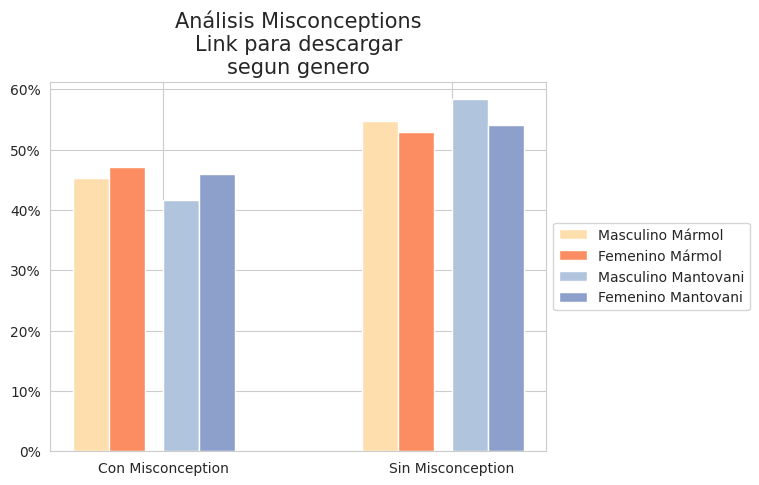

In [18]:
# Con misconception vs Sin Misconception - desagrupando No se - Link para descargar - segun genero
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 
                                1: "Femenino Mármol",
                                2: "Masculino Mantovani",
                                3: "Femenino Mantovani"},
                       index={"Los mensajes recibidos no están verificados de ninguna forma. No podemos saber si el link es seguro.": "No sabemos\n si es seguro",
                              "Los mensajes recibidos están verificados por personas en WhatsApp. El link es seguro.": "Seguros.\n Verificados\n por personas",
                              "No sé.": "No sé",
                              "Si el mensaje fue enviado por uno de mis contactos entonces el link es seguro.": "Si es de mis\n contactos\n es seguro",
                              "Los mensajes recibidos están verificados por un filtro inteligente. El link es seguro.": "Seguros.\nVerificados\n por filtro\n inteligente"}).fillna(0)

df_con_mis = result.loc[(result.index != 'No sé') & (result.index != 'No sabemos\n si es seguro')].sum()
df_sin_mis = result.loc[(result.index == 'No sé') | (result.index == 'No sabemos\n si es seguro')].sum()

result = pd.concat([df_con_mis, df_sin_mis], axis=1, ignore_index=True).rename(columns={0: "Con Misconception", 1: "Sin Misconception"}).transpose()

bar_width = 0.25

br1 = [1,3]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions\nLink para descargar\nsegun genero", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig('misconc_agreg_link_descarga_genero.png')

* No hay grandes diferencias. Las chicas eligen levemente mas las respuestas con misconc.

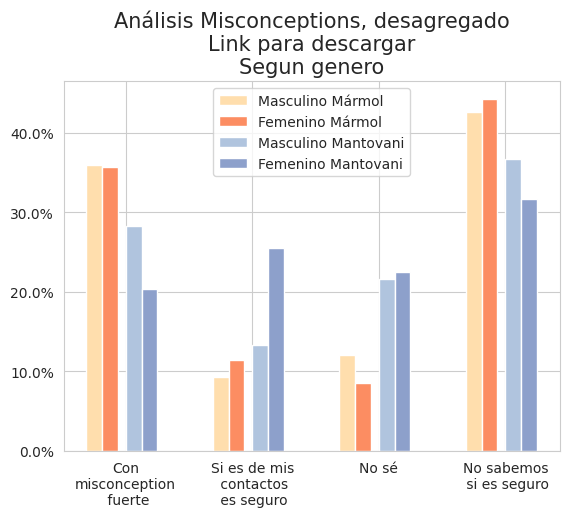

In [10]:
# Con misconception vs Sin Misconception - desagrupando No se - Link para descargar - segun genero
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 
                                1: "Femenino Mármol",
                                2: "Masculino Mantovani",
                                3: "Femenino Mantovani"},
                       index={"Los mensajes recibidos no están verificados de ninguna forma. No podemos saber si el link es seguro.": "No sabemos\n si es seguro",
                              "Los mensajes recibidos están verificados por personas en WhatsApp. El link es seguro.": "Seguros.\n Verificados\n por personas",
                              "No sé.": "No sé",
                              "Si el mensaje fue enviado por uno de mis contactos entonces el link es seguro.": "Si es de mis\n contactos\n es seguro",
                              "Los mensajes recibidos están verificados por un filtro inteligente. El link es seguro.": "Seguros.\nVerificados\n por filtro\n inteligente"}).fillna(0)

df_con_mis_fuerte = result.loc[(result.index == 'Seguros.\n Verificados\n por personas') |
                        (result.index == 'Seguros.\nVerificados\n por filtro\n inteligente')].sum()


result = pd.concat([ df_con_mis_fuerte,
                     result.loc[result.index=='Si es de mis\n contactos\n es seguro'].sum(),
                     result.loc[result.index=='No sé'].sum(),
                     result.loc[result.index=='No sabemos\n si es seguro'].sum(),
                     ], axis=1, ignore_index=True).rename(columns={0: "Con\nmisconception\n fuerte",
                                                                   1: "Si es de mis\n contactos\n es seguro",
                                                                   2: "No sé",
                                                                   3: "No sabemos\n si es seguro"}).transpose()

bar_width = 0.25

br1 = [1,3,5,7]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions, desagregado\nLink para descargar\nSegun genero", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend()
plt.savefig('misconc_desagreg_link_descarga_genero.png')

* En el modelo no hay grandes diferencias
* En el mantovani las chicas eligen menos rtas con misc fuertes. Eligen mas la misc debil, y levemente menos la rta sin misc.

## En informática, ¿qué es la nube?

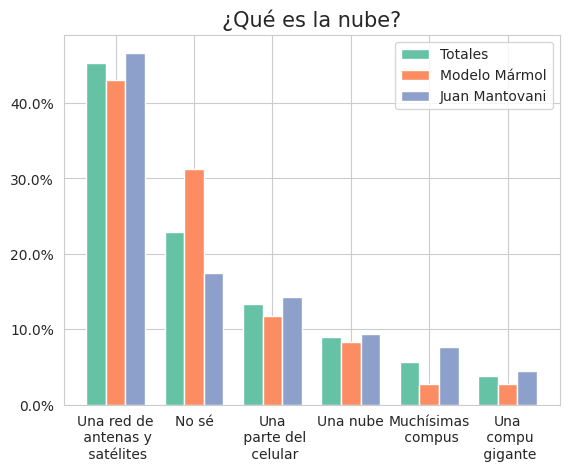

In [16]:
# En informática, ¿qué es la nube?
data_total = df_fe["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"Una red de antenas y satélites": "Una red de\n antenas y\n satélites",
                              "No sé": "No sé",
                              "Una parte del celular": "Una\n parte del\n celular",
                              "Muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\n compus",
                              "Una computadora gigante":"Una\n compu\n gigante"}).fillna(0)

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("¿Qué es la nube?", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('que_es_nube.png')

* En el mármol se elige un 10% menos la opción No se
* En el Mantovani un 5% más la opción correcta

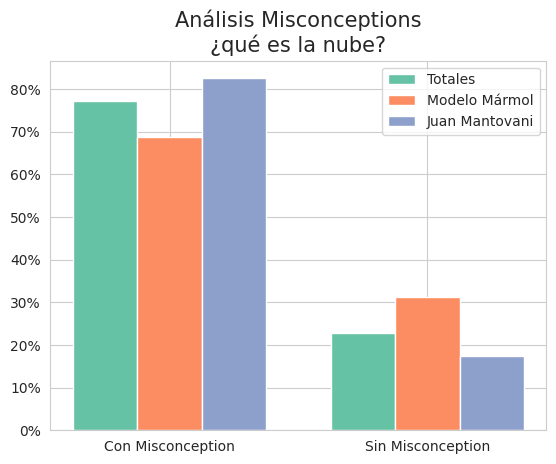

In [3]:
# Con misconception vs Sin Misconception - Agrupando No se - ¿qué es la nube?
data_total = df_fe["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"Una red de antenas y satélites": "Una red de\n antenas y\n satélites",
                              "No sé": "No sé",
                              "Una parte del celular": "Una\n parte del\n celular",
                              "Muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\n compus",
                              "Una computadora gigante":"Una\n compu\n gigante"}).fillna(0)

df_con_mis = result.loc[(result.index != 'No sé') & (result.index != 'Muchísimas computadoras')].sum()
df_sin_mis = result.loc[(result.index == 'No sé') | (result.index == 'Muchísimas computadoras')].sum()

result = pd.concat([df_con_mis, df_sin_mis], axis=1, ignore_index=True).rename(columns={0: "Con Misconception", 1: "Sin Misconception"}).transpose()

bar_width = 0.25

br1 = np.arange(len(result['Totales']))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions\n¿qué es la nube?", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('misconc_agreg_que_es_nube.png')

* En el Mantovani hay un 10% mas de respuestas con Misconception

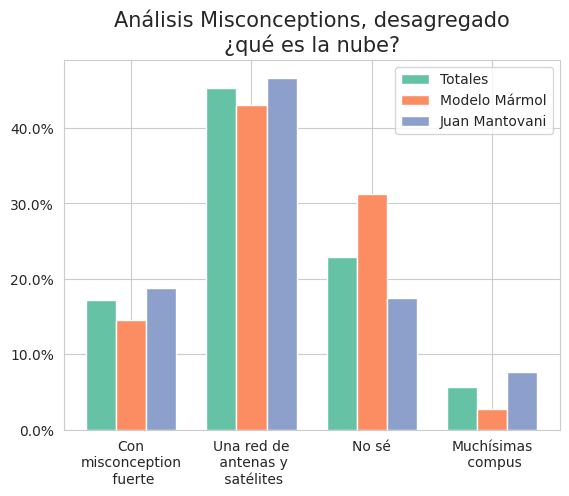

In [4]:
# Con misconception vs Sin Misconception - Desagrupando No se - ¿qué es la nube?
data_total = df_fe["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"Una red de antenas y satélites": "Una red de\n antenas y\n satélites",
                              "No sé": "No sé",
                              "Una parte del celular": "Una\n parte del\n celular",
                              "Muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\n compus",
                              "Una computadora gigante":"Una\n compu\n gigante"}).fillna(0)

df_con_mis_fuerte = result.loc[(result.index == 'Una\n parte del\n celular') |
                        (result.index == 'Una\n compu\n gigante')].sum()


result = pd.concat([ df_con_mis_fuerte,
                     result.loc[result.index=='Una red de\n antenas y\n satélites'].sum(),
                     result.loc[result.index=='No sé'].sum(),
                     result.loc[result.index=='Muchísimas\n compus'].sum(),
                     ], axis=1, ignore_index=True).rename(columns={0: "Con\nmisconception\n fuerte",
                                                                   1: "Una red de\n antenas y\n satélites",
                                                                   2: "No sé",
                                                                   3: "Muchísimas\n compus"}).transpose()

print(result.loc[])

bar_width = 0.25

br1 = np.arange(len(result['Totales']))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions, desagregado\n¿qué es la nube?", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('misconc_desagreg_que_es_nube.png')

* Ambos colegios seleccionan la misconception debil como la respuesta mas comun
* En ambos casos el Mantovani la selecciona levemente mas veces
* El modelo marmol elige no se un 10% mas que el mantovani
* El mantovani elige la respuesta correcta un 5% mas que el Modelo

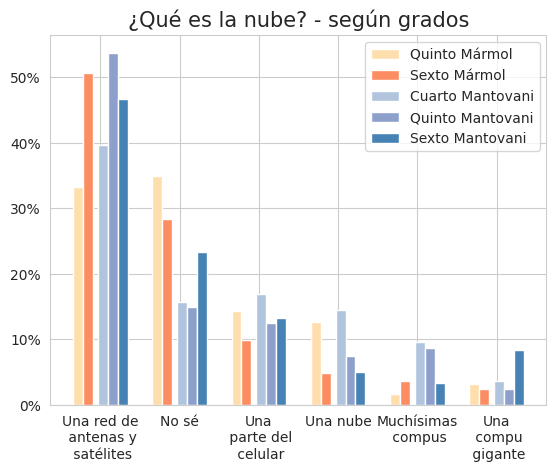

In [16]:
# En informática, ¿qué es la nube? - Grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(     columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                            index={"Una red de antenas y satélites": "Una red de\n antenas y\n satélites",
                              "No sé": "No sé",
                              "Una parte del celular": "Una\n parte del\n celular",
                              "Muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\n compus",
                              "Una computadora gigante":"Una\n compu\n gigante"}).fillna(0)

result = result.reindex(["Una red de\n antenas y\n satélites",
                         "No sé",
                         "Una\n parte del\n celular",
                         "Una nube",
                         "Muchísimas\n compus",
                         "Una\n compu\n gigante"
                         ])

br1 = [1, 3, 5, 7, 9, 11]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("¿Qué es la nube? - según grados", fontsize=15)
plt.xticks([x + 2.25*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('que_es_nube_grados.png')

* Mármol, 6to elige un 15% más "Red de antenas...", Eligen un 5% menos "Una nube" 
* Mantovani, de 4to a 6to hay un aumento de un 5% en "Red de antenas..." y "No se". Se elige un 10% menos "Una nube"

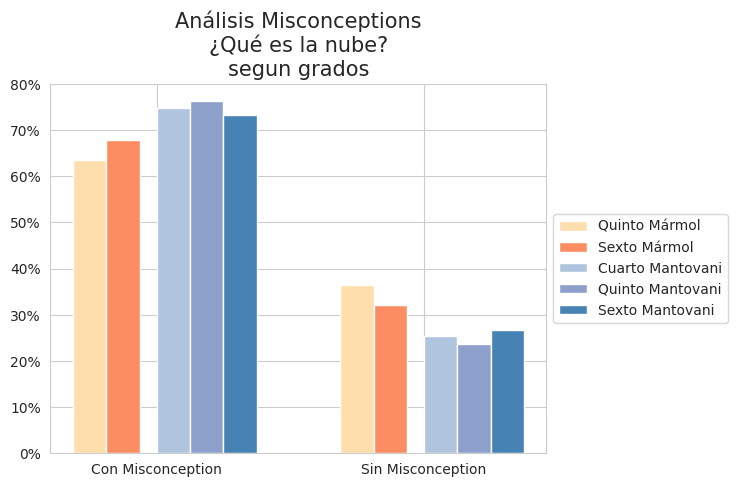

In [6]:
# Con misconception vs Sin Misconception - Agrupando No se - ¿Qué es la nube?  - segun grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                       index={"Una red de antenas y satélites": "Una red de\n antenas y\n satélites",
                              "No sé": "No sé",
                              "Una parte del celular": "Una\n parte del\n celular",
                              "Muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\n compus",
                              "Una computadora gigante":"Una\n compu\n gigante"}).fillna(0)

# print(result)

df_con_mis = result.loc[(result.index != 'No sé') & (result.index != 'Muchísimas\n compus')].sum()
df_sin_mis = result.loc[(result.index == 'No sé') | (result.index == 'Muchísimas\n compus')].sum()

result = pd.concat([df_con_mis, df_sin_mis], axis=1, ignore_index=True).rename(columns={0: "Con Misconception", 1: "Sin Misconception"}).transpose()

bar_width = 0.25

br1 = [1,3]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions\n¿Qué es la nube?\nsegun grados", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig('misconc_agreg_que_es_nube_grados.png')

* En el modelo Marmol aumentan levemente las misconceptions
* En el mantovani reducen levemente las Misconception

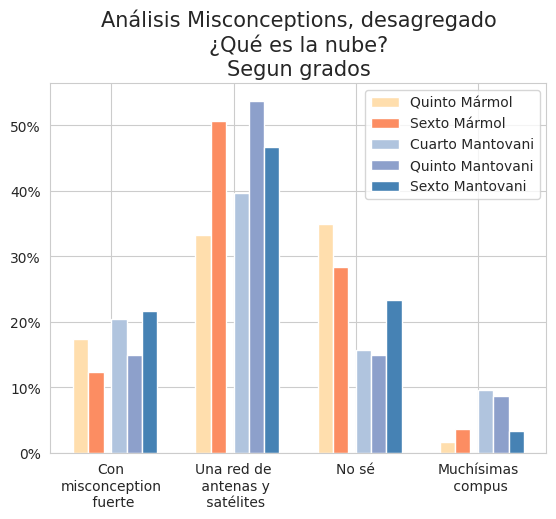

In [7]:
# Con misconception vs Sin Misconception - desagrupando No se - ¿Qué es la nube? - segun grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                       index={"Una red de antenas y satélites": "Una red de\n antenas y\n satélites",
                              "No sé": "No sé",
                              "Una parte del celular": "Una\n parte del\n celular",
                              "Muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\n compus",
                              "Una computadora gigante":"Una\n compu\n gigante"}).fillna(0)

df_con_mis_fuerte = result.loc[(result.index == 'Una\n parte del\n celular') |
                        (result.index == 'Una\n compu\n gigante')].sum()


result = pd.concat([ df_con_mis_fuerte,
                     result.loc[result.index=='Una red de\n antenas y\n satélites'].sum(),
                     result.loc[result.index=='No sé'].sum(),
                     result.loc[result.index=='Muchísimas\n compus'].sum(),
                     ], axis=1, ignore_index=True).rename(columns={0: "Con\nmisconception\n fuerte",
                                                                   1: "Una red de\n antenas y\n satélites",
                                                                   2: "No sé",
                                                                   3: "Muchísimas\n compus"}).transpose()

bar_width = 0.25

br1 = [1,3,5,7]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions, desagregado\n¿Qué es la nube?\nSegun grados", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend()
plt.savefig('misconc_desagreg_que_es_nube_grados.png')

* En el Modelo bajan las misonception fuertes mientras que en el mantovani aumentan
* En ambos colegios aumentan la misconception debil
* En el Modelo marmol se reduce el no se. En el mantovani se aumenta
* En el modelo no varia mucho la respuesta correcta. En el Mantovani se reduce.

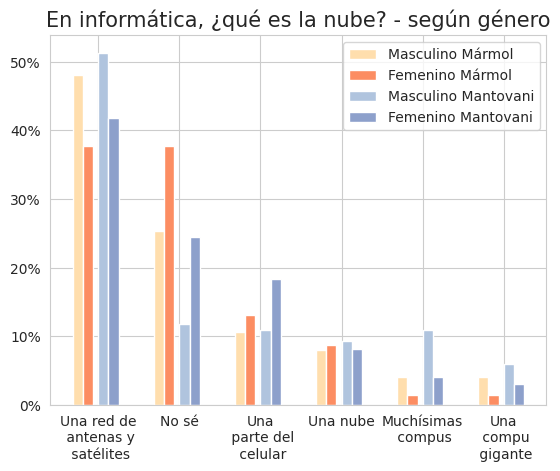

In [9]:
# En informática, ¿qué es la nube? - Género
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 1: "Femenino Mármol", 2: "Masculino Mantovani", 3: "Femenino Mantovani"},
                       index={"Una red de antenas y satélites": "Una red de\n antenas y\n satélites",
                              "No sé": "No sé",
                              "Una parte del celular": "Una\n parte del\n celular",
                              "Muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\n compus",
                              "Una computadora gigante":"Una\n compu\n gigante"}).fillna(0)

result = result.reindex(["Una red de\n antenas y\n satélites",
                         "No sé",
                         "Una\n parte del\n celular",
                         "Una nube",
                         "Muchísimas\n compus",
                         "Una\n compu\n gigante"])

bar_width = 0.25

br1 = [1, 3, 5, 7, 9, 11]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("En informática, ¿qué es la nube? - según género", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('que_es_nube_genero.png')

* Las respuestas analizadas en base al género del Modelo Mármol y Juan Mantovani son iguales:
* Las chicas eligen un 10% menos "Una red...", las chicas eligen un 10% más "No se" y un 5% más "Una parte del celular".
* Los varones del Mantovani eligen un 5% más "Muchisimas compus"

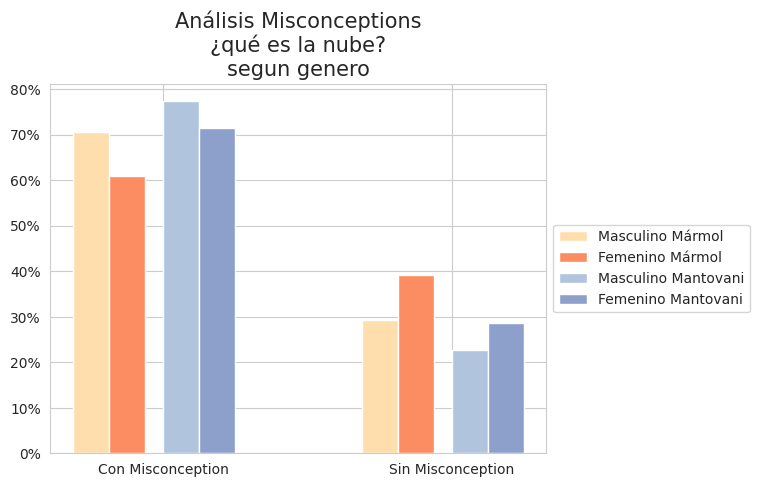

In [8]:
# Con misconception vs Sin Misconception - desagrupando No se - ¿qué es la nube? - segun genero
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 
                                1: "Femenino Mármol",
                                2: "Masculino Mantovani",
                                3: "Femenino Mantovani"},
                       index={"Una red de antenas y satélites": "Una red de\n antenas y\n satélites",
                              "No sé": "No sé",
                              "Una parte del celular": "Una\n parte del\n celular",
                              "Muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\n compus",
                              "Una computadora gigante":"Una\n compu\n gigante"}).fillna(0)

df_con_mis = result.loc[(result.index != 'No sé') & (result.index != 'Muchísimas\n compus')].sum()
df_sin_mis = result.loc[(result.index == 'No sé') | (result.index == 'Muchísimas\n compus')].sum()

result = pd.concat([df_con_mis, df_sin_mis], axis=1, ignore_index=True).rename(columns={0: "Con Misconception", 1: "Sin Misconception"}).transpose()

bar_width = 0.25

br1 = [1,3]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions\n¿qué es la nube?\nsegun genero", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig('misconc_agreg_que_es_nube_genero.png')

* En ambos colegios se reducen las misconcaptions en el sexo femenino

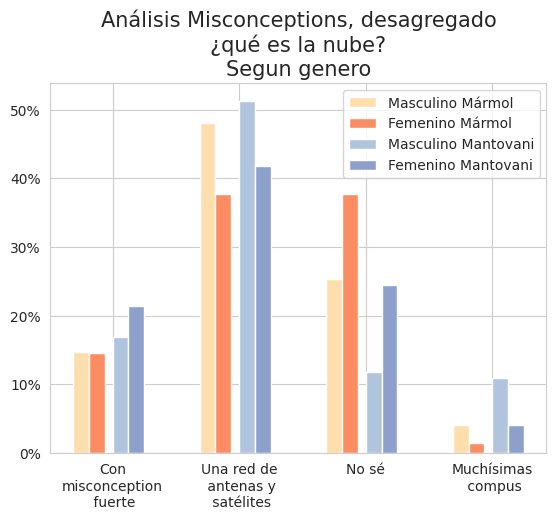

In [11]:
# Con misconception vs Sin Misconception - desagrupando No se - ¿qué es la nube? - segun genero
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 
                                1: "Femenino Mármol",
                                2: "Masculino Mantovani",
                                3: "Femenino Mantovani"},
                       index={"Una red de antenas y satélites": "Una red de\n antenas y\n satélites",
                              "No sé": "No sé",
                              "Una parte del celular": "Una\n parte del\n celular",
                              "Muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\n compus",
                              "Una computadora gigante":"Una\n compu\n gigante"}).fillna(0)

df_con_mis_fuerte = result.loc[(result.index == 'Una\n parte del\n celular') |
                        (result.index == 'Una\n compu\n gigante')].sum()


result = pd.concat([ df_con_mis_fuerte,
                     result.loc[result.index=='Una red de\n antenas y\n satélites'].sum(),
                     result.loc[result.index=='No sé'].sum(),
                     result.loc[result.index=='Muchísimas\n compus'].sum(),
                     ], axis=1, ignore_index=True).rename(columns={0: "Con\nmisconception\n fuerte",
                                                                   1: "Una red de\n antenas y\n satélites",
                                                                   2: "No sé",
                                                                   3: "Muchísimas\n compus"}).transpose()

bar_width = 0.25

br1 = [1,3,5,7]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions, desagregado\n¿qué es la nube?\nSegun genero", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend()
plt.savefig('misconc_desagreg_que_es_nube_genero.png')

* Las chicas responden levemente mas con miscon fuerte en el mantovani
* Las chicas responden 10% menos "misconc debil" que los varones
* Las chicas responden más no se en ambos colegios.
* Las chicas responden menos la opcion sin msiconception en ambos colegios

# Afirmaciones sobre la nube

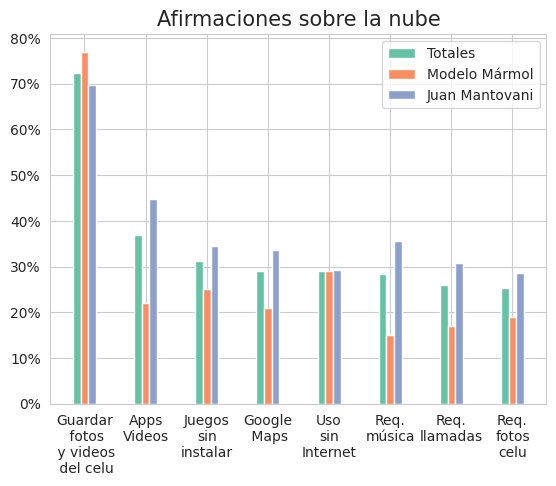

In [23]:
# Afirmaciones sobre la nube
data_total = df_fe["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total - nube_nose_totales).sort_values(ascending=False)
data_marmol = marmol["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol - nube_nose_marmol).sort_values(ascending=False)
data_mantovani = mantovani["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani - nube_nose_mantovani).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]
# print(data_total)

result = pd.concat(dfs, axis=1)
result = result.rename( columns={ 0:'Totales',
                                  1:'Modelo Mármol',
                                  2:'Juan Mantovani'},
                        index= {"Lanubemepermiteguardarlasfotosyvideosdelcelular": "Guardar\n fotos\n y videos\n del celu",
                                "InstagramyTikTokusanlanubeparacompartirsusvideos": "Apps\nVideos",
                                "Sepuedeusarlanubeparajugarjuegossininstalarlos": "Juegos\nsin\ninstalar",
                                "GoogleMapsdescargasusmapasdelanube": "Google\n Maps",
                                "PodemosutilizarlanubesinconexiónaInternet": "Uso\nsin\nInternet",
                                "Sinlanubeseríaimposibleescucharmúsicaenelcelular": "Req.\nmúsica",
                                "Sinlanubenoseríaposiblehacerllamadasporcelular": "Req.\nllamadas",
                                "Sinlanubeseríaimposiblesacarfotosconelcelular": "Req.\nfotos\ncelu"
                                }).fillna(0)

result = result.reindex(["Guardar\n fotos\n y videos\n del celu","Apps\nVideos","Juegos\nsin\ninstalar","Google\n Maps","Uso\nsin\nInternet","Req.\nmúsica","Req.\nllamadas","Req.\nfotos\ncelu"])

bar_width = 0.25

br1 = [1, 3, 5, 7, 9, 11, 13, 15]
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales']       , width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'] , width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Afirmaciones sobre la nube", fontsize=15)
plt.xticks([r + bar_width for r in br1], result.index)
plt.legend()
plt.savefig('afirmaciones_nube.png')

* En esta pregunta se permiten varias respuestas
* solo contestaban esta pregunta los chicos que habian contestado distinto a no se en la pregunta anterior
* El Mantovani elige un 25% más las respuestas "Las apps las usan para compartir sus videos" y "Sin la nube no se podría escuchar música en el celular" un 20% mas. Tambien eligen un 10% más "Permite jugar juegos sin instalarlos", "Google maps la utiliza para sus videos", "Es requerida para realizar llamadas" y "Es requerida para sacar fotos con el celular"
* Mas del 70% elige la opcion de guardar fotos y videos. El resto de las respuestas estan balanceadas en porcentaje entre 20 y 40

In [24]:
# Promedio en cantidad de respuestas - Afirmaciones sobre la nube
data_total = df_fe["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_marmol = marmol["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_mantovani = mantovani["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()

dfs = [data_total,data_marmol,data_mantovani]
labels = ['Totales','Modelo Marmol','Juan Mantovani']

result = pd.DataFrame(data=[dfs], columns=labels)
print("Promedio en cantidad de respuestas - Afirmaciones sobre la nube")
result.head()

Promedio en cantidad de respuestas - Afirmaciones sobre la nube


,Totales,Modelo Marmol,Juan Mantovani
0,2.149051,1.551724,2.535714


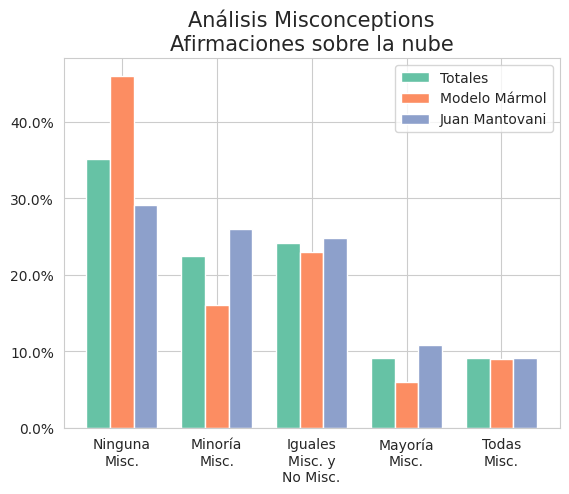

In [34]:
# Con misconception vs Sin Misconception - Agrupando No se - Afirmaciones sobre la nube
data_total = df_fe["afirmaciones_nube"].str.replace(" ", "")
data_marmol = marmol["afirmaciones_nube"].str.replace(" ", "")
data_mantovani = mantovani["afirmaciones_nube"].str.replace(" ", "")

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename( columns={ 0:'Totales',
                                  1:'Modelo Mármol',
                                  2:'Juan Mantovani'}).fillna('0')

def analizarMisc(val):
    lista = val.split(",")
    misc = 0
    not_misc = 0
    if(lista == ["0"]): # Si no seleccionaron ninguna rta, es porque contestaron no se en la pregunta anterior
        return "Sin\nRta." 
    
    # respuestas sin misconception, # not_misc
    if "Lanubemepermiteguardarlasfotosyvideosdelcelular" in lista:
        not_misc = not_misc + 1
    if "InstagramyTikTokusanlanubeparacompartirsusvideos" in lista:
        not_misc = not_misc + 1
    if "Sepuedeusarlanubeparajugarjuegossininstalarlos" in lista:
        not_misc = not_misc + 1
    if "GoogleMapsdescargasusmapasdelanube" in lista:
        not_misc = not_misc + 1

    # respuestas con misconception, # misc
    if "PodemosutilizarlanubesinconexiónaInternet" in lista:
        misc = misc + 1
    if "Sinlanubeseríaimposibleescucharmúsicaenelcelular" in lista:
        misc = misc + 1
    if "Sinlanubenoseríaposiblehacerllamadasporcelular" in lista:
        misc = misc + 1
    if "Sinlanubeseríaimposiblesacarfotosconelcelular" in lista:
        misc = misc + 1
    
    if(not_misc == misc):
        return "Iguales\nMisc. y\nNo Misc."    
    if(misc == 0):
        return "Ninguna\nMisc."        
    if(not_misc == 0):
        return "Todas\nMisc."      
    if(not_misc > misc):        
        return "Minoría\nMisc."    
    if(misc > not_misc):
        return "Mayoría\nMisc." 


dfs = [result["Totales"].apply(analizarMisc).value_counts(),
       result["Modelo Mármol"].apply(analizarMisc).value_counts(),
       result["Juan Mantovani"].apply(analizarMisc).value_counts()]


result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"})

result = result.reindex(["Sin\nRta.", 
                         "Ninguna\nMisc.",
                         "Minoría\nMisc.", 
                         "Iguales\nMisc. y\nNo Misc.",
                         "Mayoría\nMisc.",
                         "Todas\nMisc."])
# restamos las no respuestas de los valores null de los correspondientes colegios
result.at['Sin\nRta.', 'Modelo Mármol'] = result.loc['Sin\nRta.','Modelo Mármol'] - cant_mantovani
result.at['Sin\nRta.', 'Juan Mantovani'] = result.loc['Sin\nRta.','Juan Mantovani'] - cant_marmol

result = result.drop("Sin\nRta.")
# no las vamos a graficar (estamos graficando solo a los que responden la pregunta y sacando promedio con el nro de respuestas por colegio)
# aun asi mantengo el calculo por si las utilizamos en algun momento

bar_width = 0.25

br1 = np.arange(len(result['Totales']))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'].div(cant_total - nube_nose_totales)             , width=bar_width , label = 'Totales')
plt.bar(br2,result['Modelo Mármol'].div(cant_marmol - nube_nose_marmol)       , width=bar_width , label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'].div(cant_mantovani - nube_nose_mantovani), width=bar_width , label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions\nAfirmaciones sobre la nube", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('misconc_afirmaciones_nube.png')

* Se dividieron las respuestas con misc. y las que no, se agruparon las respuestas de cada individuo en 5 categorías para representar el gradiente de "misconceptions" en cuanto a afirmaciones sobre la nube.
* Felizmente, el porcentaje más alto es el que se corresponde a los que eligen entre sus respuestas un conjunto que no tiene misconceptions.
* Minoría de Misconceptions e iguales cantidades se distribuyen de manera similar en el mantovani, cerca de un 20%, en el Mármol este porcentaje está cerca de 15%.
* Finalmente la minoría corresponde a mayoría de misconceptions o todas misconceptions.
* A grandes rasgos, cerca de un 60% contesta mayormente sin misconceptions en el Modelo mármol y cerca de un 55% en el Mantovani.
* Cerca de un 15% contesta con mayoría de misconceptions en el Modelo Mármol y el Mantovani

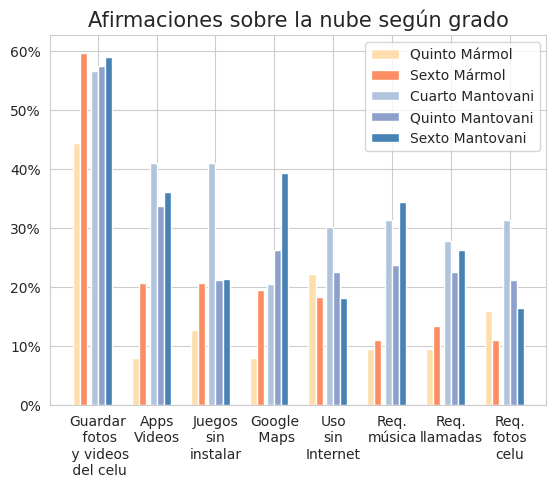

In [32]:
# Afirmaciones sobre la nube según grado
data_total = df_fe["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)

data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol_quinto).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol_sexto).sort_values(ascending=False)

data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani_cuarto).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani_quinto).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani_sexto).sort_values(ascending=False)

dfs = [data_marmol_quinto, data_marmol_sexto, data_mantovani_cuarto, data_mantovani_quinto, data_mantovani_sexto]

result = pd.concat(dfs, axis=1)
result = result.rename( columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                        index= {"Lanubemepermiteguardarlasfotosyvideosdelcelular": "Guardar\n fotos\n y videos\n del celu",
                                "InstagramyTikTokusanlanubeparacompartirsusvideos": "Apps\nVideos",
                                "Sepuedeusarlanubeparajugarjuegossininstalarlos": "Juegos\nsin\ninstalar",
                                "GoogleMapsdescargasusmapasdelanube": "Google\n Maps",
                                "PodemosutilizarlanubesinconexiónaInternet": "Uso\nsin\nInternet",
                                "Sinlanubeseríaimposibleescucharmúsicaenelcelular": "Req.\nmúsica",
                                "Sinlanubenoseríaposiblehacerllamadasporcelular": "Req.\nllamadas",
                                "Sinlanubeseríaimposiblesacarfotosconelcelular": "Req.\nfotos\ncelu"
                                }).fillna(0)

result = result.reindex(["Guardar\n fotos\n y videos\n del celu","Apps\nVideos","Juegos\nsin\ninstalar","Google\n Maps","Uso\nsin\nInternet","Req.\nmúsica","Req.\nllamadas","Req.\nfotos\ncelu"])

bar_width = 0.12

ticks = np.arange(len(result))

br_marmol_quinto = ticks
br_marmol_sexto = [x + bar_width for x in br_marmol_quinto]

br_mantovani_cuarto = [x + 1.5* bar_width for x in br_marmol_sexto]
br_mantovani_quinto = [x + bar_width for x in br_mantovani_cuarto]
br_mantovani_sexto  = [x + bar_width for x in br_mantovani_quinto]

plt.bar(br_marmol_quinto,    result['Quinto Mármol'], width=bar_width, label = 'Quinto Mármol'      , color='navajowhite')
plt.bar(br_marmol_sexto,     result['Sexto Mármol'], width=bar_width, label = 'Sexto Mármol'        , color='C1')
plt.bar(br_mantovani_cuarto, result['Cuarto Mantovani'], width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br_mantovani_quinto, result['Quinto Mantovani'], width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br_mantovani_sexto,  result['Sexto Mantovani'], width=bar_width, label = 'Sexto Mantovani'  , color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Afirmaciones sobre la nube según grado", fontsize=15)
ticks = [x + 3*bar_width for x in ticks]
plt.xticks(ticks, result.index)
plt.legend()

plt.savefig('afirmaciones_nube_grado.png')

* En esta pregunta se permiten varias respuestas
* Mármol: "Guardar fotos y videos..." es elegida un 15% más en 6to. "Las apps las usan para compartir..." es elegida un 10% más junto con "Google maps"
* Mantovani: Curiosamente, la opción de "Juegos sin instalar" es elegida un 20% menos en 5to y 6to. "Google maps", un 20% más en 6to y finalmente "Uso sin internet" y "Requerida para sacar fotos con el celu" bajan un 10% y 15% respectivamente. 

In [12]:
# Promedio en cantidad de respuestas - Afirmaciones sobre la nube según grado
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]
labels = ['Quinto Marmol','Sexto Marmol','Cuarto Mantovani','Quinto Mantovani','Sexto Mantovani']

result = pd.DataFrame(data=[dfs], columns=labels)
print("Promedio en cantidad de respuestas - Afirmaciones sobre la nube según grado")
result.head()

Promedio en cantidad de respuestas - Afirmaciones sobre la nube según grado


,Quinto Marmol,Sexto Marmol,Cuarto Mantovani,Quinto Mantovani,Sexto Mantovani
0,1.301587,1.743902,2.795181,2.2875,2.508197


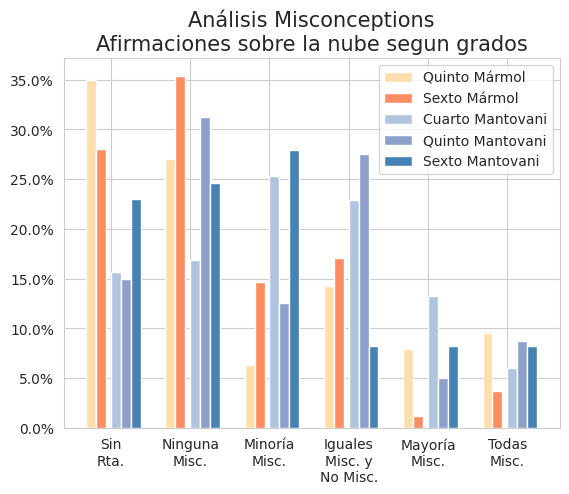

In [39]:
# Con misconception vs Sin Misconception - Agrupando No se - Afirmaciones sobre la nube
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["afirmaciones_nube"].str.replace(" ", "")
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["afirmaciones_nube"].str.replace(" ", "")

data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["afirmaciones_nube"].str.replace(" ", "")
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["afirmaciones_nube"].str.replace(" ", "")
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["afirmaciones_nube"].str.replace(" ", "")

dfs = [data_marmol_quinto, data_marmol_sexto, data_mantovani_cuarto, data_mantovani_quinto, data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename( columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'}).fillna('0')

def analizarMisc(val):
    lista = val.split(",")
    misc = 0
    not_misc = 0
    if(lista == ["0"]): # Si no seleccionaron ninguna rta, es porque contestaron no se en la pregunta anterior
        return "Sin\nRta." 
    
    # respuestas sin misconception, # not_misc
    if "Lanubemepermiteguardarlasfotosyvideosdelcelular" in lista:
        not_misc = not_misc + 1
    if "InstagramyTikTokusanlanubeparacompartirsusvideos" in lista:
        not_misc = not_misc + 1
    if "Sepuedeusarlanubeparajugarjuegossininstalarlos" in lista:
        not_misc = not_misc + 1
    if "GoogleMapsdescargasusmapasdelanube" in lista:
        not_misc = not_misc + 1

    # respuestas con misconception, # misc
    if "PodemosutilizarlanubesinconexiónaInternet" in lista:
        misc = misc + 1
    if "Sinlanubeseríaimposibleescucharmúsicaenelcelular" in lista:
        misc = misc + 1
    if "Sinlanubenoseríaposiblehacerllamadasporcelular" in lista:
        misc = misc + 1
    if "Sinlanubeseríaimposiblesacarfotosconelcelular" in lista:
        misc = misc + 1
    
    if(not_misc == misc):
        return "Iguales\nMisc. y\nNo Misc."    
    if(misc == 0):
        return "Ninguna\nMisc."        
    if(not_misc == 0):
        return "Todas\nMisc."      
    if(not_misc > misc):        
        return "Minoría\nMisc."    
    if(misc > not_misc):
        return "Mayoría\nMisc." 


dfs = [result["Quinto Mármol"].apply(analizarMisc).value_counts(),
       result["Sexto Mármol"].apply(analizarMisc).value_counts(),
       result["Cuarto Mantovani"].apply(analizarMisc).value_counts(),
       result["Quinto Mantovani"].apply(analizarMisc).value_counts(),
       result["Sexto Mantovani"].apply(analizarMisc).value_counts()]


result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'})

result = result.reindex(["Sin\nRta.", 
                         "Ninguna\nMisc.",
                         "Minoría\nMisc.", 
                         "Iguales\nMisc. y\nNo Misc.",
                         "Mayoría\nMisc.",
                         "Todas\nMisc."])


# restamos las no respuestas de los valores null de los correspondientes colegios (!!! falta sumar los grados !!)
result.at['Sin\nRta.', 'Quinto Mármol'] = result.loc['Sin\nRta.','Quinto Mármol'] - cant_mantovani  - cant_marmol_sexto
result.at['Sin\nRta.', 'Sexto Mármol'] = result.loc['Sin\nRta.','Sexto Mármol'] - cant_mantovani - cant_marmol_quinto
result.at['Sin\nRta.', 'Cuarto Mantovani'] = result.loc['Sin\nRta.','Cuarto Mantovani'] - cant_marmol - cant_mantovani_quinto - cant_mantovani_sexto
result.at['Sin\nRta.', 'Quinto Mantovani'] = result.loc['Sin\nRta.','Quinto Mantovani'] - cant_marmol - cant_mantovani_cuarto - cant_mantovani_sexto
result.at['Sin\nRta.', 'Sexto Mantovani'] = result.loc['Sin\nRta.','Sexto Mantovani'] - cant_marmol - cant_mantovani_cuarto - cant_mantovani_quinto

# print(result)
bar_width = 0.25

br1 = [1,3,5,7,9,11]
br2 = [x + bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x + bar_width for x in br3]
br5 = [x + bar_width for x in br4]

plt.bar(br1,result['Quinto Mármol'].div(cant_marmol_quinto)      , width=bar_width , label = "Quinto Mármol"       , color='navajowhite')
plt.bar(br2,result['Sexto Mármol'].div(cant_marmol_sexto)        , width=bar_width        , label = "Sexto Mármol" , color='C1')
plt.bar(br3,result['Cuarto Mantovani'].div(cant_mantovani_cuarto), width=bar_width     , label = "Cuarto Mantovani", color='lightsteelblue')
plt.bar(br4,result['Quinto Mantovani'].div(cant_mantovani_quinto), width=bar_width     , label = "Quinto Mantovani", color='C2')
plt.bar(br5,result['Sexto Mantovani'].div(cant_mantovani_sexto)  , width=bar_width      , label = "Sexto Mantovani", color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions\nAfirmaciones sobre la nube segun grados", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend()
plt.savefig('misconc_afirmaciones_nube_grado.png')

* En el marmol baja levemente el porcentaje que no responde esta pregunta en sexto.
* En el Mantovani, aumenta el porcentaje que no responde en sexto
* En el modelo y mantovani aumenta con los grados los que contestan mayormente sin misconception

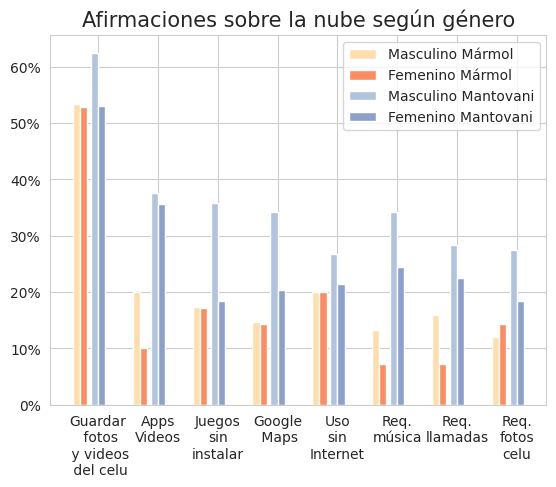

In [13]:
# Afirmaciones sobre la nube
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol_masc).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol_fem).sort_values(ascending=False)

data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani_masc).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani_fem).sort_values(ascending=False)

dfs = [data_marmol_mas, data_marmol_fem, data_mantovani_mas, data_mantovani_fem]

result = pd.concat(dfs, axis=1)
result = result.rename( columns={0: "Masculino Mármol",
                                1: "Femenino Mármol",
                                2: "Masculino Mantovani",
                                3: "Femenino Mantovani"},
                        index= {"Lanubemepermiteguardarlasfotosyvideosdelcelular": "Guardar\n fotos\n y videos\n del celu",
                                "InstagramyTikTokusanlanubeparacompartirsusvideos": "Apps\nVideos",
                                "Sepuedeusarlanubeparajugarjuegossininstalarlos": "Juegos\nsin\ninstalar",
                                "GoogleMapsdescargasusmapasdelanube": "Google\n Maps",
                                "PodemosutilizarlanubesinconexiónaInternet": "Uso\nsin\nInternet",
                                "Sinlanubeseríaimposibleescucharmúsicaenelcelular": "Req.\nmúsica",
                                "Sinlanubenoseríaposiblehacerllamadasporcelular": "Req.\nllamadas",
                                "Sinlanubeseríaimposiblesacarfotosconelcelular": "Req.\nfotos\ncelu"
                                }).fillna(0)

result = result.reindex(["Guardar\n fotos\n y videos\n del celu","Apps\nVideos","Juegos\nsin\ninstalar","Google\n Maps","Uso\nsin\nInternet","Req.\nmúsica","Req.\nllamadas","Req.\nfotos\ncelu"])

bar_width = 0.12

ticks = np.arange(len(result))

b1 = ticks
b2 = [x + bar_width for x in b1]
b3 = [x + 1.5* bar_width for x in b2]
b4 = [x + bar_width for x in b3]

plt.bar(b1,result["Masculino Mármol"]   , width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(b2,result["Femenino Mármol"]    , width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(b3,result["Masculino Mantovani"], width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(b4,result["Femenino Mantovani"] , width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Afirmaciones sobre la nube según género", fontsize=15)
ticks = [x + 3*bar_width for x in ticks]
plt.xticks(ticks, result.index)
plt.legend()

plt.savefig('afirmaciones_nube_genero.png')

* En esta pregunta se permiten varias respuestas
* Mármol: las chicas eligen un 10% menos la opción "las apps la usan para compartir sus videos".
* Mantovani: Las chicas eligen un 10% menos la opcion "guardar fotos y videos del celu". También eligen un 15% menos "jugar juegos sin isntalar" y "Maps la usa para sus mapas". El resto de las respuestas también tienen un menor porcentaje de elección en las mujeres.

In [14]:
# Promedio en cantidad de respuestas - Afirmaciones sobre la nube según género
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]
labels = ["Masculino Marmol","Femenino Marmol","Masculino Mantovani","Femenino Mantovani"]

result = pd.DataFrame(data=[dfs], columns=labels)
print("Promedio en cantidad de respuestas - Afirmaciones sobre la nube según género")
result.head()

Promedio en cantidad de respuestas - Afirmaciones sobre la nube según género


,Masculino Marmol,Femenino Marmol,Masculino Mantovani,Femenino Mantovani
0,1.666667,1.428571,2.866667,2.142857


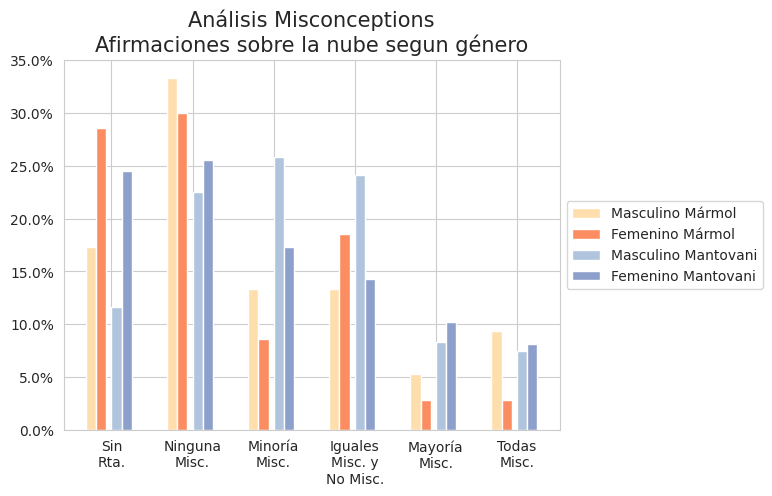

In [8]:
# Con misconception vs Sin Misconception - Agrupando No se - Afirmaciones sobre la nube
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["afirmaciones_nube"].str.replace(" ", "")
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["afirmaciones_nube"].str.replace(" ", "")

data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["afirmaciones_nube"].str.replace(" ", "")
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["afirmaciones_nube"].str.replace(" ", "")

dfs = [data_marmol_mas, data_marmol_fem, data_mantovani_mas, data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename( columns={0: "Masculino Mármol",
                                 1: "Femenino Mármol",
                                 2: "Masculino Mantovani",
                                 3: "Femenino Mantovani"}).fillna('0')

def analizarMisc(val):
    lista = val.split(",")
    misc = 0
    not_misc = 0
    if(lista == ["0"]): # Si no seleccionaron ninguna rta, es porque contestaron no se en la pregunta anterior
        return "Sin\nRta." 
    
    # respuestas sin misconception, # not_misc
    if "Lanubemepermiteguardarlasfotosyvideosdelcelular" in lista:
        not_misc = not_misc + 1
    if "InstagramyTikTokusanlanubeparacompartirsusvideos" in lista:
        not_misc = not_misc + 1
    if "Sepuedeusarlanubeparajugarjuegossininstalarlos" in lista:
        not_misc = not_misc + 1
    if "GoogleMapsdescargasusmapasdelanube" in lista:
        not_misc = not_misc + 1

    # respuestas con misconception, # misc
    if "PodemosutilizarlanubesinconexiónaInternet" in lista:
        misc = misc + 1
    if "Sinlanubeseríaimposibleescucharmúsicaenelcelular" in lista:
        misc = misc + 1
    if "Sinlanubenoseríaposiblehacerllamadasporcelular" in lista:
        misc = misc + 1
    if "Sinlanubeseríaimposiblesacarfotosconelcelular" in lista:
        misc = misc + 1
    
    if(not_misc == misc):
        return "Iguales\nMisc. y\nNo Misc."    
    if(misc == 0):
        return "Ninguna\nMisc."        
    if(not_misc == 0):
        return "Todas\nMisc."      
    if(not_misc > misc):        
        return "Minoría\nMisc."    
    if(misc > not_misc):
        return "Mayoría\nMisc." 


dfs = [result["Masculino Mármol"].apply(analizarMisc).value_counts(),
       result["Femenino Mármol"].apply(analizarMisc).value_counts(),
       result["Masculino Mantovani"].apply(analizarMisc).value_counts(),
       result["Femenino Mantovani"].apply(analizarMisc).value_counts()]


result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol",
                                 1: "Femenino Mármol",
                                 2: "Masculino Mantovani",
                                 3: "Femenino Mantovani"})

result = result.reindex(["Sin\nRta.", 
                         "Ninguna\nMisc.",
                         "Minoría\nMisc.", 
                         "Iguales\nMisc. y\nNo Misc.",
                         "Mayoría\nMisc.",
                         "Todas\nMisc."])

# restamos las no respuestas de los valores null de los correspondientes colegios (!!! falta sumar los grados !!)
result.at['Sin\nRta.', "Masculino Mármol"] = result.loc['Sin\nRta.',"Masculino Mármol"] - cant_mantovani  - cant_marmol_fem
result.at['Sin\nRta.', "Femenino Mármol"] = result.loc['Sin\nRta.',"Femenino Mármol"] - cant_mantovani - cant_marmol_masc
result.at['Sin\nRta.', "Masculino Mantovani"] = result.loc['Sin\nRta.',"Masculino Mantovani"] - cant_marmol - cant_mantovani_fem
result.at['Sin\nRta.', "Femenino Mantovani"] = result.loc['Sin\nRta.',"Femenino Mantovani"] - cant_marmol - cant_mantovani_masc

bar_width = 0.25

br1 = [1,3,5,7,9,11]
br2 = [x + bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x + bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"].div(cant_marmol_masc)      , width=bar_width, label = "Masculino Mármol"   , color='navajowhite')
plt.bar(br2,result["Femenino Mármol"].div(cant_marmol_fem)        , width=bar_width, label = "Femenino Mármol"    , color='C1')
plt.bar(br3,result["Masculino Mantovani"].div(cant_mantovani_masc), width=bar_width, label = "Masculino Mantovani", color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"].div(cant_mantovani_fem)  , width=bar_width, label = "Femenino Mantovani" , color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions\nAfirmaciones sobre la nube segun género", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig('misconc_afirmaciones_nube_genero.png')

* En ambos colegios, las chicas eligen un 15% más no se en la pregunta anterior, como consecuencia no responden esta pregunta.
* En el modelo marmol, los varones responden un 15% más sin mayoría de misconceptions. En el mantovani los resultados para ninguna misconc son similares, pero los varones tienen un 5% más de respuestas con minoría de misc.
* En cuanto a cantidades iguales de misc y no misc, los varones responden un 10% más con igual cantidad de misc y no misc.
* Los varones del modelo mármol eligen un conjunto de respuestas en las que todas son misc un 5% más que las chicas.

# Cómo se comportan Internet y la nube

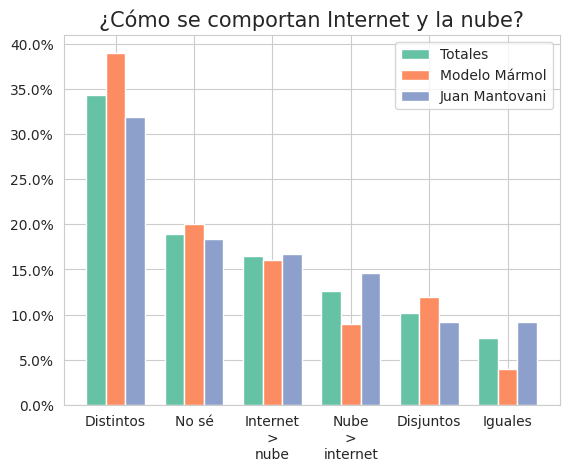

In [74]:
# Cómo se comportan Internet y la nube
data_total = df_fe["como_se_comportan"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["como_se_comportan"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["como_se_comportan"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)

result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"Internet y la nube tienen algunas funciones comunes y algunas funciones distintas.": "Distintos",
                              "No sé.": "No sé",
                              "Con Internet podemos hacer más cosas que con la nube.": "Internet\n>\nnube",
                              "Con la nube podemos hacer más cosas que con Internet.": "Nube\n>\ninternet",
                              "Internet y la nube no tienen funciones en común.":"Disjuntos",
                              "Podemos hacer exactamente lo mismo con Internet que con la nube.": "Iguales"}).fillna(0)

result = result.reindex(["Distintos", "No sé","Internet\n>\nnube","Nube\n>\ninternet","Disjuntos","Iguales"])

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("¿Cómo se comportan Internet y la nube?", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('como_se_comportan.png')

In [ ]:
# Con misconception vs Sin Misconception - Agrupando No se - Cómo se comportan Internet y la nube
data_total = df_fe["como_se_comportan"].str.replace(" ", "")
data_marmol = marmol["como_se_comportan"].str.replace(" ", "")
data_mantovani = mantovani["como_se_comportan"].str.replace(" ", "")

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename( columns={ 0:'Totales',
                                  1:'Modelo Mármol',
                                  2:'Juan Mantovani'}).fillna('0')

def analizarMisc(val):
    lista = val.split(",")
    misc = 0
    not_misc = 0
    if(lista == ["0"]): # Si no seleccionaron ninguna rta, es porque contestaron no se en la pregunta anterior
        return "Sin\nRta." 
    
    # respuestas sin misconception, # not_misc
    if "Lanubemepermiteguardarlasfotosyvideosdelcelular" in lista:
        not_misc = not_misc + 1
    if "InstagramyTikTokusanlanubeparacompartirsusvideos" in lista:
        not_misc = not_misc + 1
    if "Sepuedeusarlanubeparajugarjuegossininstalarlos" in lista:
        not_misc = not_misc + 1
    if "GoogleMapsdescargasusmapasdelanube" in lista:
        not_misc = not_misc + 1

    # respuestas con misconception, # misc
    if "PodemosutilizarlanubesinconexiónaInternet" in lista:
        misc = misc + 1
    if "Sinlanubeseríaimposibleescucharmúsicaenelcelular" in lista:
        misc = misc + 1
    if "Sinlanubenoseríaposiblehacerllamadasporcelular" in lista:
        misc = misc + 1
    if "Sinlanubeseríaimposiblesacarfotosconelcelular" in lista:
        misc = misc + 1
    
    if(not_misc == misc):
        return "Iguales\nMisc. y\nNo Misc."    
    if(misc == 0):
        return "Ninguna\nMisc."        
    if(not_misc == 0):
        return "Todas\nMisc."      
    if(not_misc > misc):        
        return "Minoría\nMisc."    
    if(misc > not_misc):
        return "Mayoría\nMisc." 


dfs = [result["Totales"].apply(analizarMisc).value_counts(),
       result["Modelo Mármol"].apply(analizarMisc).value_counts(),
       result["Juan Mantovani"].apply(analizarMisc).value_counts()]


result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"})

result = result.reindex(["Sin\nRta.", 
                         "Ninguna\nMisc.",
                         "Minoría\nMisc.", 
                         "Iguales\nMisc. y\nNo Misc.",
                         "Mayoría\nMisc.",
                         "Todas\nMisc."])
# restamos las no respuestas de los valores null de los correspondientes colegios
result.at['Sin\nRta.', 'Modelo Mármol'] = result.loc['Sin\nRta.','Modelo Mármol'] - cant_mantovani
result.at['Sin\nRta.', 'Juan Mantovani'] = result.loc['Sin\nRta.','Juan Mantovani'] - cant_marmol

bar_width = 0.25

br1 = np.arange(len(result['Totales']))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'].div(cant_total)           , width=bar_width , label = 'Totales')
plt.bar(br2,result['Modelo Mármol'].div(cant_marmol)    , width=bar_width , label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'].div(cant_mantovani), width=bar_width , label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Análisis Misconceptions\nAfirmaciones sobre la nube", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('misconc_como_se_comportan.png')

* No hay diferencias mayores a 5% en las respuestas de ambos colegios

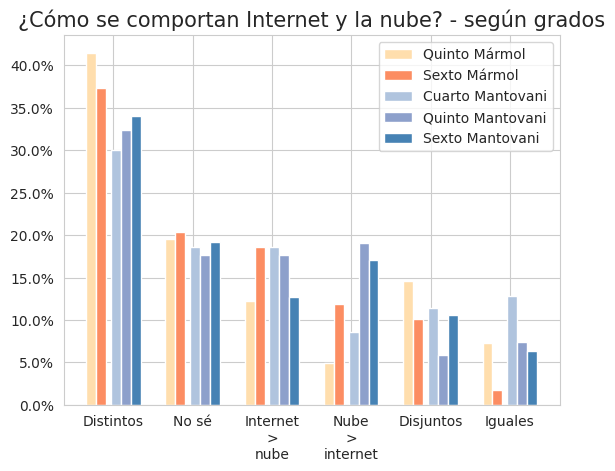

In [75]:
# Cómo se comportan Internet y la nube - Grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["como_se_comportan"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["como_se_comportan"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["como_se_comportan"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["como_se_comportan"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["como_se_comportan"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(     columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                       index={"Internet y la nube tienen algunas funciones comunes y algunas funciones distintas.": "Distintos",
                              "No sé.": "No sé",
                              "Con Internet podemos hacer más cosas que con la nube.": "Internet\n>\nnube",
                              "Con la nube podemos hacer más cosas que con Internet.": "Nube\n>\ninternet",
                              "Internet y la nube no tienen funciones en común.":"Disjuntos",
                              "Podemos hacer exactamente lo mismo con Internet que con la nube.": "Iguales"}).fillna(0)

result = result.reindex(["Distintos", "No sé","Internet\n>\nnube","Nube\n>\ninternet","Disjuntos","Iguales"])

br1 = [1, 3, 5, 7, 9, 11]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("¿Cómo se comportan Internet y la nube? - según grados", fontsize=15)
plt.xticks([x + 2.25*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('como_se_comportan_grados.png')

* La única diferencia notoria entre grados es entre 4to y 6to del Mantovani, eligiendo que la funcionalidad de la nube es mayor a la del internet un 10% más en 6to.

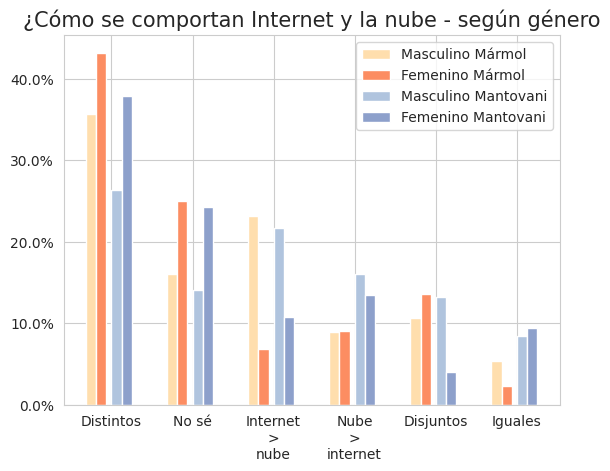

In [77]:
# Cómo se comportan Internet y la nube - Género
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["como_se_comportan"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["como_se_comportan"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["como_se_comportan"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["como_se_comportan"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 1: "Femenino Mármol", 2: "Masculino Mantovani", 3: "Femenino Mantovani"},
                       index={"Internet y la nube tienen algunas funciones comunes y algunas funciones distintas.": "Distintos",
                              "No sé.": "No sé",
                              "Con Internet podemos hacer más cosas que con la nube.": "Internet\n>\nnube",
                              "Con la nube podemos hacer más cosas que con Internet.": "Nube\n>\ninternet",
                              "Internet y la nube no tienen funciones en común.":"Disjuntos",
                              "Podemos hacer exactamente lo mismo con Internet que con la nube.": "Iguales"}).fillna(0)

result = result.reindex(["Distintos", "No sé","Internet\n>\nnube","Nube\n>\ninternet","Disjuntos","Iguales"])

bar_width = 0.25

br1 = [1, 3, 5, 7, 9, 11]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("¿Cómo se comportan Internet y la nube - según género", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('como_se_comportan_genero.png')

* Los chicos del modelo eligen un 15% más "Internet > nube".
* Las chicas del mantovani eligen un 10% más "Distintos" y "No se". Mientras que los chicos, como en el modelo mármol, eligen un 10% más "Internet > nube".

# ¿Conocés o alguna vez usaste Wikipedia?

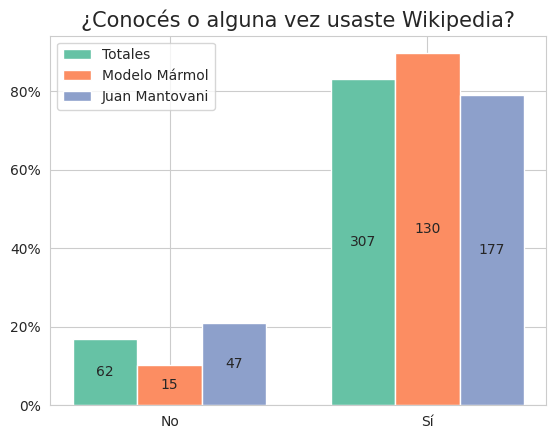

In [82]:
# # ¿Conocés o alguna vez usaste Wikipedia?
dfs = [df["uso_wikipedia"].value_counts() for df in [df_fe, marmol, mantovani]]
result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 
                                1: "Modelo Mármol", 
                                2: "Juan Mantovani"}
                                ).fillna(0).astype('Int64').sort_index()

cantidades = [ result["Totales"].to_numpy(),
               result["Modelo Mármol"].to_numpy(), 
               result["Juan Mantovani"].to_numpy()]

bar_width = 0.25
br1 = np.arange(len(result["Totales"]))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

fig, ax = plt.subplots()

plt.bar(br1,result["Totales"].div(cant_total)           , width=bar_width, label = 'Totales')
plt.bar(br2,result["Modelo Mármol"].div(cant_marmol)    , width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result["Juan Mantovani"].div(cant_mantovani), width=bar_width, label = 'Juan Mantovani')

i = 0
for bars in ax.containers:
    ax.bar_label(bars, labels=cantidades[i], label_type="center")
    i=i+1

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("¿Conocés o alguna vez usaste Wikipedia?", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()

plt.savefig('uso_wikipedia.png')

* No hay grandes diferencias en porcentajes. Notemos que perderemos un 20% de los alumnos del Mantovani en la siguiente pregunta y un 10% del Modelo Mármol respectivamente.

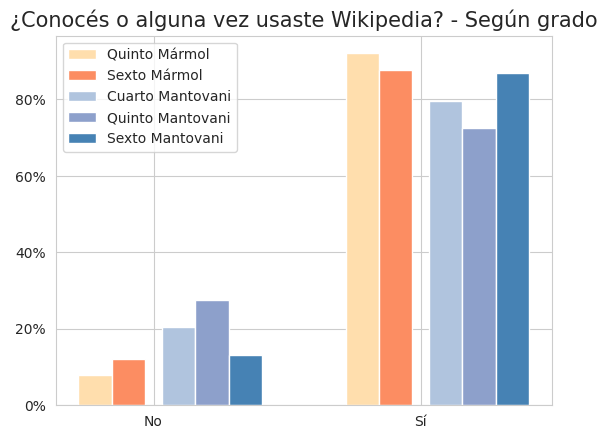

In [15]:
# ¿Conocés o alguna vez usaste Wikipedia? - Grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["uso_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["uso_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["uso_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["uso_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["uso_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'})

result = result.reindex(["No","Sí"])

bar_width = 0.25

br1 = [1, 3]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("¿Conocés o alguna vez usaste Wikipedia? - Según grado", fontsize=15)
plt.xticks([x + 1.75*bar_width for x in br1], result.index)
plt.legend()
plt.savefig('uso_wikipedia_grados.png')


* El porcentaje de alumnos de 5to en el modelo es un 10% y un 15% en 6to
* Los alumnos del mantovani se reducen en un 20% en 4to, casi 30% en 5to y 15% en sexto

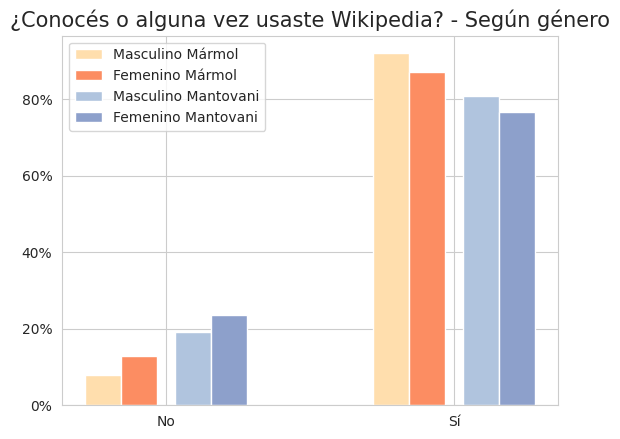

In [16]:
# ¿Conocés o alguna vez usaste Wikipedia? - Género
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["uso_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["uso_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["uso_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["uso_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 1: "Femenino Mármol", 2: "Masculino Mantovani", 3: "Femenino Mantovani"})

result = result.reindex(["No","Sí"])

bar_width = 0.25

br1 = [1, 3]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("¿Conocés o alguna vez usaste Wikipedia? - Según género", fontsize=15)
plt.xticks([x + 1.75*bar_width for x in br1], result.index)
plt.legend()
plt.savefig('uso_wikipedia_genero.png')


* No hay grandes diferencias por genero. En Marmol están centrados en 10% y en el Mantovani en 20%

# Sobre los artículos de Wikipedia

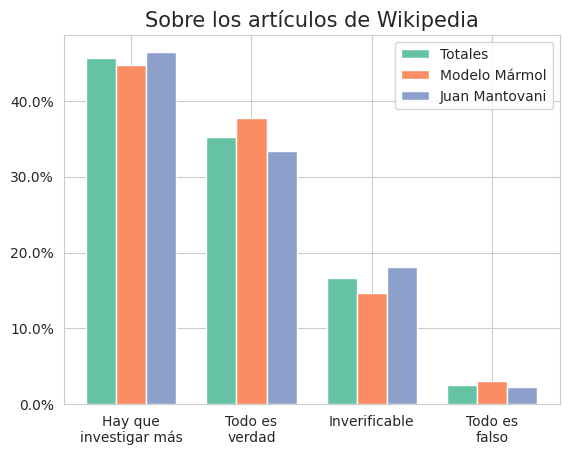

In [104]:
# Sobre los artículos de Wikipedia
data_total = df_fe["sobre_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["sobre_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["sobre_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"Hace falta investigar más para decidir si la información es verdadera o falsa.": "Hay que\ninvestigar más",
                              "Toda la información en el artículo es verdadera porque está verificada.": "Todo es\nverdad",
                              "No hay forma de saber si la información del artículo es verdadera o falsa.": "Inverificable",
                              "Todo lo que está en el artículo es falso: cualquier usuario pudo haberlo inventado.": "Todo es\nfalso"}).fillna(0)

result = result.reindex(["Hay que\ninvestigar más","Todo es\nverdad","Inverificable","Todo es\nfalso"])

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Sobre los artículos de Wikipedia", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('sobre_wikipedia.png')

* No hay diferencias entre colegios para esta respuesta

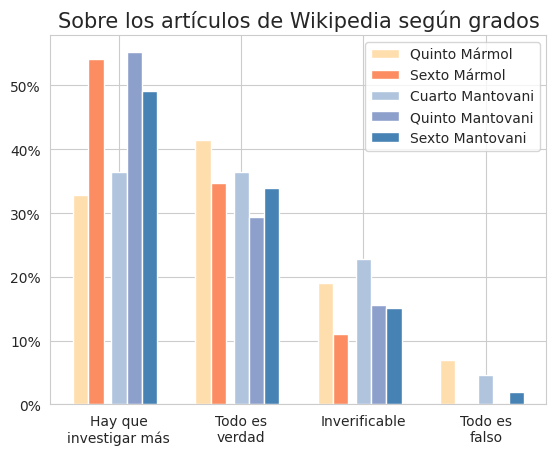

In [108]:
# Sobre los artículos de Wikipedia - Grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["sobre_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["sobre_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["sobre_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["sobre_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["sobre_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                       index={"Hace falta investigar más para decidir si la información es verdadera o falsa.": "Hay que\ninvestigar más",
                              "Toda la información en el artículo es verdadera porque está verificada.": "Todo es\nverdad",
                              "No hay forma de saber si la información del artículo es verdadera o falsa.": "Inverificable",
                              "Todo lo que está en el artículo es falso: cualquier usuario pudo haberlo inventado.": "Todo es\nfalso"}).fillna(0)

result = result.reindex(["Hay que\ninvestigar más","Todo es\nverdad","Inverificable","Todo es\nfalso"])

bar_width = 0.25

br1 = [1, 3, 5, 7]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Sobre los artículos de Wikipedia según grados", fontsize=15)
plt.xticks([x + 2.5*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('sobre_wikipedia_grados.png')


* En el modelo mármol, los alumnos de 6to eligen un 20% más la opción "Hay que investigar más" y cerca de un 10% menos "Inverificable"
* En el mantovani se elige un 15% más "Hay que investigar más" a medida que avanzan de curso.

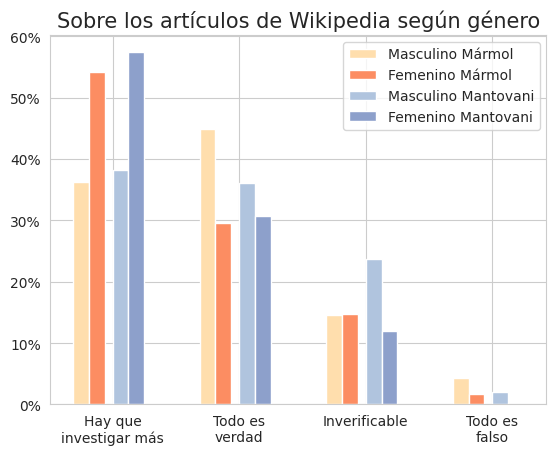

In [111]:
# Sobre los artículos de Wikipedia - Género
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["sobre_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["sobre_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["sobre_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["sobre_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 1: "Femenino Mármol", 2: "Masculino Mantovani", 3: "Femenino Mantovani"},
                       index={"Hace falta investigar más para decidir si la información es verdadera o falsa.": "Hay que\ninvestigar más",
                              "Toda la información en el artículo es verdadera porque está verificada.": "Todo es\nverdad",
                              "No hay forma de saber si la información del artículo es verdadera o falsa.": "Inverificable",
                              "Todo lo que está en el artículo es falso: cualquier usuario pudo haberlo inventado.": "Todo es\nfalso"}).fillna(0)

result = result.reindex(["Hay que\ninvestigar más","Todo es\nverdad","Inverificable","Todo es\nfalso"])

bar_width = 0.25

br1 = [1, 3, 5, 7]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Sobre los artículos de Wikipedia según género", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('sobre_wikipedia_genero.png')

* Las chicas en el Mármol eligen un 15% más "Hay que investigar más" y un 15% menos "Todo es verdad"
* Las chicas del Mantovani eligen casi un 20% más "Hay que investigar más" y un 10% menos "Inverificable"
* El comportamiento de las chicas para "Hay que investigar más" se repite en ambos colegios.